## Exercise 4: SPECTER Embeddings and Principal Component Analysis

In [7]:
from transformers import AutoTokenizer, AutoModel
import tqdm
import numpy as np

# Load the SPECTER model and tokenizer
tokenizer = AutoTokenizer.from_pretrained('allenai/specter')
model = AutoModel.from_pretrained('allenai/specter')

/Users/luischan/miniconda3/lib/python3.11/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [9]:
# Example format of papers dict
papers = {
    "39351497": {
        "ArticleTitle": "Memory-related hippocampal brain-derived neurotrophic factor activation pathways from repetitive transcranial magnetic stimulation in the 3xTg-AD mouse line.",
        "AbstractText": "Alzheimer's disease is associated with a loss of plasticity and cognitive functioning. Previous research has shown that repetitive transcranial magnetic stimulation (rTMS) boosts cortical neurotrophic factors, potentially addressing this loss. The current study aimed to expand these findings by measuring brain-derived neurotrophic factor (BDNF), its downstream hippocampal signaling molecules, and behavioral effects of rTMS on the 3xTg-AD mouse line. 3xTg-AD (n = 24) and B6 wild-type controls (n = 26), aged 12 months, were given 14 days of consecutive rTMS at 10 Hz for 10 min. Following treatment, mice underwent a battery of behavioral tests and biochemical analysis of BDNF and its downstream cascades were evaluated via Western blot and ELISA. Results showed that brain stimulation did improve performance on the Object Place Task and increased hippocampal TrkB, ERK, and PLC\u03b3 in 3xTg-AD mice with minimal effects on wild-type mice. There was no significant difference in the levels of AKT and Truncated TrkB (TrkB.T1) between treatment and sham. Thus, rTMS has the potential to provide an efficacious non-invasive therapy for the treatment of Alzheimer's disease through activation of neurotrophic factor signaling.",
        "query": "Alzheimer"
    },
    "39291144": {
        "ArticleTitle": "Identification of high-performing antibodies for SPARC-related modular calcium-binding protein 1 (SMOC-1) for use in Western Blot and immunoprecipitation.",
        "AbstractText": "SPARC-related modular calcium-binding protein 1, otherwise known as SMOC-1, is a secreted glycoprotein involved in various cell biological processes including cell-matrix interactions, osteoblast differentiation, embryonic development, and homeostasis. SMOC-1 was found to be elevated in asymptomatic Alzheimer's disease (AD) patient cortex as well as being enriched in amyloid plaques and in AD patientcerebrospinal fluid, arguing for SMOC-1 as a promising biomarker for AD. Having access to high-quality SMOC-1 antibodies is crucial for the scientific community. It can ensure the consistency and reliability of SMOC-1 research, and further the exploration of its potential as both a therapeutic target or diagnostic marker.. In this study, we characterized seven SMOC-1 commercial antibodies for Western blot and immunoprecipitation, using a standardized experimental protocol based on comparing read-outs in knockout cell lines and isogenic parental controls. We identified successful antibodies in the tested applications and encourage readers to use this report as a guide to select the most appropriate antibody for their specific needs.",
        "query": "Alzheimer"
    },
    "39195962": {
        "ArticleTitle": "Lower risk of Alzheimer's disease with CHIP.",
        "AbstractText": "",
        "query": "Alzheimer"
    },
    "39073326": {
        "ArticleTitle": "The effects of nitric oxide in Alzheimer's disease.",
        "AbstractText": "Alzheimer's disease (AD), the most prevalent cause of dementia, is a progressive neurodegenerative condition that commences subtly and inexorably worsens over time. Despite considerable research, a specific drug that can fully cure or effectively halt the progression of AD remains elusive. Nitric oxide (NO), a crucial signaling molecule in the nervous system, is intimately associated with hallmark pathological changes in AD, such as amyloid-beta deposition and tau phosphorylation. Several therapeutic strategies for AD operate through the nitric oxide synthase/NO system. However, the potential neurotoxicity of NO introduces an element of controversy regarding its therapeutic utility in AD. This review focuses on research findings concerning NO's role in experimental AD and its underlying mechanisms. Furthermore, we have proposed directions for future research based on our current comprehension of this critical area.",
        "query": "Alzheimer"
    },
    "38845738": {
        "ArticleTitle": "Considerations When Designing and Implementing Pragmatic Clinical Trials That Include Older Hispanics.",
        "AbstractText": "INTRODUCTION: Pragmatic clinical trials (PCTs) are designed to connect researchers with clinicians to assess the real-world effectiveness and feasibility of interventions, treatments, or health care delivery strategies in routine practice. Within PCTs larger, more representative sampling is possible to improve the external validity of the research. Older adults from underrepresented groups can benefit from PCTs given their historically lower engagement in clinical research. The current article focuses on older Hispanic adults with Alzheimer disease and related dementias (ADRDs). Older Hispanic adults represent 19% of the US population and have a higher prevalence of ADRDs than Whites. We provide data from 2 PCTs about the recruitment of older Hispanics with ADRDs and discuss unique challenges associated with conducting PCTs and propose strategies to overcome challenges.\nDATA AND METHODS: The first PCT outlined is the Patient Priorities Care for Hispanics with Dementia (PPC-HD) trial. PPC-HD is testing the feasibility of implementing a culturally adapted version of the Patient Priorities Care approach for older Hispanic adults with multiple chronic conditions and dementia. The second PCT is the Dementia Care (D-CARE) Study, which is a multisite pragmatic study comparing the effectiveness of a health care system-based approach and a community-based approach to dementia care to usual care in patients with ADRDs and their family caregivers.\nLESSONS LEARNED AND RECOMMENDATIONS FOR FUTURE STUDIES: The lessons learned are summarized according to the various stakeholders that need to work together to effectively recruit diverse participants for PCTs: individuals, health care systems, research teams, and communities. Individual-level considerations include communication, priorities, and flexibility. Health care system-level considerations are grounded in 4 principles of Community-Based Participatory Research and include collaboration/partnership, available resources, priorities of the health care system, and sustainability. Research team-level considerations include team members, intentionality, and communication. Community-level considerations highlight the importance of partnerships, community members, and appropriate incentives.\nDISCUSSION: PCTs provide a unique and potentially impactful opportunity to test interventions in real-world settings that must be culturally appropriate to reach underrepresented groups. Collectively, considering variables at multiple levels to address the needs of older adults with ADRDs is crucial, and the examples and suggestions provided in this report are a foundation for future research.",
        "query": "Alzheimer"
    },
    "38812995": {
        "ArticleTitle": "Correlation of metal ions with specific brain region volumes in neurodegenerative diseases.",
        "AbstractText": "BACKGROUND/AIM: There are reports stating that deteriorations in metal homeostasis in neurodegenerative diseases promote abnormal protein accumulation. In this study, the serum metal levels in Alzheimer's disease (AD) and Parkinson's disease (PD) and its relationship with the cortical regions of the brain were investigated.\nMATERIALS AND METHODS: The patients were divided into 3 groups consisting of the AD group, PD group, and healthy control group (n = 15 for each). The volumes of specific brain regions were measured over the participants' 3-dimensional magnetic resonance images, and they were compared across the groups. Copper, zinc, iron, and ferritin levels in the serums were determined, and their correlations with the brain region volumes were examined.\nRESULTS: The volumes of left hippocampus and right substantia nigra were lower in the AD and PD groups, while the volume of the left nucleus caudatus (CdN) and bilateral insula were lower in the AD group compared to the control group. Serum zinc levels were lower in the AD and PD groups, while the iron level was lower in the PD group in comparison to the control group. In addition, the serum ferritin level was higher in the AD group than in the control group. Serum zinc and copper levels in the AD group were positively correlated with the volumes of the right entorhinal cortex, thalamus, CdN, and insula. Serum zinc and copper levels in the PD group showed a negative correlation with the left nucleus accumbens (NAc), right putamen, and right insula volumes. While the serum ferritin level in the PD group displayed a positive correlation with the bilateral CdN, putamen, and NAc, as well as the right hippocampus and insula volumes, no area was detected that showed a correlation with the serum ferritin level in the AD group.\nCONCLUSION: A relationship was determined between the serum metal levels in the AD and PD groups and certain brain cortical regions that showed volumetric changes, which can be important for the early diagnosis of neurodegenerative diseases.",
        "query": "Alzheimer"
    },
    "38783740": {
        "ArticleTitle": "Rational design synthesis and evaluation of a novel near-infrared fluorescent probe for selective imaging of amyloid-\u03b2 aggregates in Alzheimer's disease.",
        "AbstractText": "Alzheimer's disease (AD) is a degenerative neurological disorder that remains incurable to date, seriously affecting the quality of life and health of those affected. One of the key neuropathological hallmarks of AD is the formation of amyloid-\u03b2 (A\u03b2) plaques. Near-infrared (NIR) probes that possess a large Stokes shift show great potential for imaging of A\u03b2 plaques in vivo and in vitro. Herein, we proposed a rational strategy for design and synthesis of a series of NIR fluorescent probes that incorporate a tricarbonitrile group as a strong electron-withdrawing group (EWG) to enable NIR emission and large Stokes shift for optimal imaging of A\u03b2 plaques. The probe TCM-UM exhibited remarkable in vitro performance, including strong NIR emission (\u03bbem\u00a0=\u00a0670\u00a0nm), large Stokes shift (120-245\u00a0nm), and its affinity for A\u03b242 aggregates (Kd\u00a0=\u00a043.78\u00a0\u00b1\u00a04.09\u00a0nM) was superior to the commercially available probe Thioflavin T (ThT, Kd\u00a0=\u00a0896.04\u00a0\u00b1\u00a033.43\u00a0nM). Further, TCM-UM was selected for imaging A\u03b2 plaques in brain tissue slices and APP/PS1 transgenic (AD) mice, the results indicated that TCM-UM had an excellent ability to penetrate the blood-brain barrier (BBB) compared with ThT, and it could effectively distinguish wild-type (Wt) mice and APP/PS1 transgenic (AD) mice.",
        "query": "Alzheimer"
    },
    "38700041": {
        "ArticleTitle": "Facilitated lexical processing accuracy and reaction times following repetitive Transcranial Magnetic Stimulation in dementia of the Alzheimer type: a case study.",
        "AbstractText": "We investigated the potential effects of high-frequency (10\u2009Hz) repetitive Transcranial Magnetic Stimulation (rTMS) of the bilateral Dorsolateral Prefrontal Cortex (DLPFC) (30-sessions; 2-sessions/day) on improving lexical processing in one participant with mild - Alzheimer's disease (hereafter dementia of the Alzheimer type-DAT). Increased accuracy and faster reaction times (RTs) were reported in a lexical-decision task (LDT) up to 2-months post-intervention. The current findings indicate that high-frequency stimulation of the DLPFC might be a potential therapeutic tool to improve lexical processing in mild-DAT.",
        "query": "Alzheimer"
    },
    "38678309": {
        "ArticleTitle": "The effects of deep transcranial magnetic stimulation on Alzheimer's disease: a case report examining cognitive functioning, memory, and QEEG.",
        "AbstractText": "Numerous treatment options are being studied for Alzheimer's disease (AD) given the rising prevalence of this condition worldwide. Transcranial Magnetic Stimulation (TMS) is a promising option for regulating specific neurological abnormalities pertaining to this condition. This case presents a patient with AD and co-occurring major depressive disorder that received 36 sessions of Deep TMS to the frontal and temporal lobes. This patient experienced improved general cognitive functioning and memory, remission from depression, and reduced slow-frequency theta activity in frontal and temporal sites. Following 7\u2009months of weekly maintenance, additional improvements occurred. This report suggests that Deep TMS may be effective in mitigating AD symptoms, and maintenance sessions are advisable.",
        "query": "Alzheimer"
    },
    "38661357": {
        "ArticleTitle": "Correlation between APOE4 gene and gut microbiota in Alzheimer's disease.",
        "AbstractText": "Gut microbiota (GM) dysbiosis has been increasingly associated with Alzheimer's disease (AD). However, the association between APOE4, the most common genetic risk factor for sporadic AD, and GM in AD remains unclear. In this study, we conducted a comparative analysis of the GM of participants from China and the USA, with and without APOE4 genes and with or without AD (67 AD cases, 67 control cases). Our results revealed that the GM alpha diversity was not different between groups (AD_APOE4, Control_APOE4, AD_non-APOE4, and Control_non-APOE4) (419.031\u00a0\u00b1 143.631 vs 391.091\u00a0\u00b1 126.081, 351.086\u00a0\u00b1 169.174 and 386.089\u00a0\u00b1 177.200, respectively. P > 0.05). Interestingly, individuals in the AD_APOE4 group had different bacterial compositions and bacterial biomarkers. The Kruskal-Wallis rank sum test indicated that the abundances of many bacterial species in the AD_APOE4 patients differed from those in control individuals, including decreases in unclassified_g__Escherichia-Shigella (1.763\u00a0\u00b1 6.73, 4.429\u00a0\u00b1 11.13, 8.245\u00a0\u00b1 16.55, and 5.69\u00a0\u00b1 13.91 in four groups, respectively; P < 0.05), and unclassified_g_Clostridium_sensu_stricto_1 (0.1519\u00a0\u00b1 0.348, 2.502\u00a0\u00b1 5.913, 0.5146\u00a0\u00b1 0.9487, 1.063\u00a0\u00b1 3.428 in four groups, respectively; P < 0.05), and increases in gut_metagenome_g_Faecalibacterium (2.885\u00a0\u00b1 4.47, 2.174\u00a0\u00b1 3.957, 0.5765\u00a0\u00b1 1.784, 1.582\u00a0\u00b1 2.92 in four groups, respectively. P < 0.01) and unclassified_g_Bacteroides (3.875\u00a0\u00b1 3.738, 2.47\u00a0\u00b1 2.748, 2.046\u00a0\u00b1 3.674, 3.206\u00a0\u00b1 3.446 in four groups, respectively; P < 0.05). In the KEGG pathway level 2 analysis, we identified three significant differences in relative abundances of predicted functions between AD_APOE4 and AD_non-APOE4_carrier groups: neurodegenerative diseases (0.0007\u00a0\u00b1 0.0005 vs 0.0009\u00a0\u00b1 0.0004; P < 0.01), metabolism (0.0240\u00a0\u00b1 0.0003 vs 0.0250\u00a0\u00b1 0.0003; P < 0.05), and biosynthesis of other secondary metabolites (0.0094\u00a0\u00b1 0.0002 vs 0.0090\u00a0\u00b1 0.0002; P < 0.05). Receiver operating characteristic curves further demonstrated an area under the curve (AUC) of 0.74 for the discrimination of AD_APOE4_carrier and AD_non-APOE4_carrier individuals.",
        "query": "Alzheimer"
    },
    "38462447": {
        "ArticleTitle": "Serotonin Receptors as a Potential Target in the Treatment of Alzheimer's Disease.",
        "AbstractText": "Alzheimer's disease (AD) is the most common cause of dementia worldwide that has an increasing impact on aging societies. Besides its critical role in the control of various physiological functions and behavior, brain serotonin (5-HT) system is involved in the regulation of migration, proliferation, differentiation, maturation, and programmed death of neurons. At the same time, a growing body of evidence indicates the involvement of 5-HT neurotransmission in the formation of insoluble aggregates of \u03b2-amyloid and tau protein, the main histopathological signs of AD. The review describes the role of various 5-HT receptors and intracellular signaling cascades induced by them in the pathological processes leading to the development of AD, first of all, in protein aggregation. Changes in the functioning of certain types of 5-HT receptors or associated intracellular signaling mediators prevent accumulation of \u03b2-amyloid plaques and tau protein neurofibrillary tangles. Based on the experimental data, it can be suggested that the use of 5-HT receptors as new drug targets will not only improve cognitive performance in AD, but will be also important in treating the causes of AD-related dementia.",
        "query": "Alzheimer"
    },
    "38462444": {
        "ArticleTitle": "Changes in the Glutamate/GABA System in the Hippocampus of Rats with Age and during Alzheimer's Disease Signs Development.",
        "AbstractText": "GABA and glutamate are the most abundant neurotransmitters in the CNS and play a pivotal part in synaptic stability/plasticity. Glutamate and GABA homeostasis is important for healthy aging and reducing the risk of various neurological diseases, while long-term imbalance can contribute to the development of neurodegenerative disorders, including Alzheimer's disease (AD). Normalization of the homeostasis has been discussed as a promising strategy for prevention and/or treatment of AD, however, data on the changes in the GABAergic and glutamatergic systems with age, as well as on the dynamics of AD development, are limited. It is not clear whether imbalance of the excitatory/inhibitory systems is the cause or the consequence of the disease development. Here we analyzed the age-related alterations of the levels of glutamate, GABA, as well as enzymes that synthesize them (glutaminase, glutamine synthetase, GABA-T, and GAD67), transporters (GLAST, GLT-1, and GAT1), and relevant receptors (GluA1, NMDAR1, NMDA2B, and GABAAr1) in the whole hippocampus of the Wistar rats and of the senescence-accelerated OXYS rats, a model of the most common (> 95%) sporadic AD. Our results suggest that there is a decline in glutamate and GABA signaling with age in hippocampus of the both rat strains. However, we have not identified significant changes or compensatory enhancements in this system in the hippocampus of OXYS rats during the development of neurodegenerative processes that are characteristic of AD.",
        "query": "Alzheimer"
    },
    "38409713": {
        "ArticleTitle": "Antipsychotics in Alzheimer's Disease: Current Status and Therapeutic Alternatives.",
        "AbstractText": "Psychosis and hyperactive behaviors, such as agitation and wandering, affect a significant proportion of patients with Alzheimer's disease (AD). These symptoms are often treated with antipsychotics, usually in an off-label approach. This mini-review provides an updated perspective on the pharmacological approach for the neuropsychiatric symptoms (NPS) in AD. The results of new studies have provided a better understanding of AD-related NPS management, but high-quality evidence still needs to be obtained. Herein, we argue for a more cautious approach to the use of antipsychotics in AD and highlight the importance of exploring alternative treatments for NPS. By doing so, we can ensure that patients with AD receive optimal care that is both effective and safe.",
        "query": "Alzheimer"
    },
    "38381472": {
        "ArticleTitle": "9-cis beta-carotene-enriched diet significantly improved cognition and decreased Alzheimer's disease neuropathology and neuroinflammation in Alzheimer's disease-like mouse models.",
        "AbstractText": "A significant progressive decline in beta-carotene (\u03b2C) levels in the brain is associated with cognitive impairment and a higher prevalence of Alzheimer's disease (AD). In this study, we investigated whether the administration of 9-cis beta-carotene (9CBC)-rich powder of the alga Dunaliella bardawil, the best-known source of \u03b2C in nature, inhibits the development of AD-like neuropathology and cognitive deficits. We demonstrated that in 3 AD mouse models, Tg2576, 5xFAD, and apoE4, 9CBC treatment improved long- and short-term memory, decreased neuroinflammation, and reduced the prevalence of \u03b2-amyloid plaques and tau hyperphosphorylation. These findings suggest that 9CBC has the potential to be an effective preventive and symptomatic AD therapy.",
        "query": "Alzheimer"
    },
    "38376885": {
        "ArticleTitle": "In vivo tau is associated with change in memory and processing speed, but not reasoning, in cognitively unimpaired older adults.",
        "AbstractText": "The relationship between tau deposition and cognitive decline in cognitively healthy older adults is still unclear. The tau PET tracer 18F-MK-6240 has shown favorable imaging characteristics to identify early tau deposition in aging. We evaluated the relationship between in vivo tau levels (18F-MK-6240) and retrospective cognitive change over 5 years in episodic memory, processing speed, and reasoning. For tau quantification, a set of regions of interest (ROIs) was selected a priori based on previous literature: (1) total-ROI comprising selected areas, (2) medial temporal lobe-ROI, and (3) lateral temporal lobe-ROI and cingulate/parietal lobe-ROI. Higher tau burden in most ROIs was associated with a steeper decline in memory and speed. There were no associations between tau and reasoning change. The novelty of this finding is that tau burden may affect not only episodic memory, a well-established finding but also processing speed. Our finding reinforces the notion that early tau deposition in areas related to Alzheimer's disease is associated with cognitive decline in cognitively unimpaired individuals, even in a sample with low amyloid-\u03b2 pathology.",
        "query": "Alzheimer"
    },
    "38357957": {
        "ArticleTitle": "Toxic Advanced Glycation End-Products-Dependent Alzheimer's Disease- Like Alternation in the Microtubule System.",
        "AbstractText": "Type 2 diabetes mellitus (T2DM) is a risk factor for Alzheimer's Disease (AD). However, the detailed mechanism underlying T2DM-related AD remains unknown. In DM, many types of advanced glycation end-products (AGEs) are formed and accumulated. In our previous study, we demonstrated that Glyceraldehyde (GA)-derived Toxic Advanced Glycation End-products (Toxic AGEs, TAGE) strongly showed cytotoxicity against neurons and induced similar alterations to those observed in AD. Further, GA induced dysfunctional neurite outgrowth via TAGE-\u03b2-- tubulin aggregation, which resulted in the TAGE-dependent abnormal aggregation of \u03b2-tubulin and tau phosphorylation. Herein, we provide a perspective on the possibility that T2DM increases the probability of AD onset and accelerates its progression.",
        "query": "Alzheimer"
    },
    "38357915": {
        "ArticleTitle": "A quantitative review of competing learning slope metrics: effects of age, sex, and clinical diagnosis.",
        "AbstractText": "INTRODUCTION: In learning and memory tests that involve multiple presentations of the same material, learning slope refers to the degree to which examinees improve performances over successive learning trials. We aimed to quantitatively review the traditional raw learning slope (RLS), and the newly created learning ratio (LR) to understand the effects of demographic variables and clinical diagnoses on learning slope (e.g., limited improvement over multiple trials), and to develop demographically sensitive norms.\nMETHOD: A systematic literature search was conducted to evaluate the potential for these aims to be examined across the most popular contemporary multi-trial learning tests. Two databases were searched. Following this, hierarchical linear modeling was used to examine how demographic variables predict learning slope indices. These results were in turn used to contrast the performance of clinical groups with the predicted performance of demographically similar healthy controls. Finally, preliminary normative estimates for learning slope indices were presented.\nRESULTS: A total of 82 studies met criteria for inclusion in this study. However, the Rey Auditory Verbal Learning Test (RAVLT) was the only test to have sufficient trial-level learning and demographic data. Fifty-eight samples from 19 studies were quantitatively examined. Hierarchical linear models provided evidence of sex differences and a curvilinear decline in learning slope with age, with strongest and most consistent effects for LR relative to RLS. Regression-based norms for demographically corrected RLS and LR scores for the RAVLT are presented. The effect of clinical diagnoses was consistently stronger for LR, and Alzheimer's disease had the strongest effect, followed by invalid performances, severe traumatic brain injury, and seizures/epilepsy.\nCONCLUSION: Overall, LR enjoys both conceptual and demonstrated psychometric advantages over RLS. Replication of these findings can be completed by reanalyzing existing datasets. Further work may focus on the utility of using LR in diagnosis and prediction of clinical prognosis.",
        "query": "Alzheimer"
    },
    "38357803": {
        "ArticleTitle": "A review on nonviral, nonbacterial infectious agents toxicity involved in neurodegenerative diseases.",
        "AbstractText": "Neuronal death, decreased activity or dysfunction of neurotransmitters are some of the pathophysiological reasons for neurodegenerative diseases like Alzheimer's, Parkinson's and multiple sclerosis. Also, there is evidence for the role of infections and infectious agents in neurodegenerative diseases and the effect of some metabolites in microorganisms in the pathophysiology of these diseases. In this study, we intend to evaluate the existing studies on the role of infectious agents and their metabolites on the pathophysiology of neurodegenerative diseases. PubMed, Scopus, Google Scholar and Web of Science search engines were searched. Some infectious agents have been observed in neurodegenerative diseases. Also, isolations of some fungi and microalgae have an improving effect on Parkinson's and Alzheimer's.",
        "query": "Alzheimer"
    },
    "38321895": {
        "ArticleTitle": "Microglia ",
        "AbstractText": "Alzheimer's disease (AD) is a highly hereditary disease with complex genetic susceptibility factors. Extensive genome-wide association studies have established a distinct susceptibility link between the protein tyrosine kinase 2\u03b2 (PTK2B) gene and late-onset Alzheimer's disease (LOAD), but the specific pathogenic mechanisms remain incompletely understood. PTK2B is known to be expressed in neurons, and recent research has revealed its more important significance in microglia. Elucidating the role of PTK2B high expression in microglia in AD's progression is crucial for uncovering novel pathogenic mechanisms of the disease. Our review of existing studies suggests a close relationship between PTK2B/proline-rich tyrosine kinase 2 (Pyk2) and tau pathology, and this process might be \u03b2-amyloid (A\u03b2) dependence. Pyk2 is hypothesized as a pivotal target linking A\u03b2 and tau pathologies. Concurrently, A\u03b2-activated Pyk2 participates in the regulation of microglial activation and its proinflammatory functions. Consequently, it is reasonable to presume that Pyk2 in microglia contributes to amyloid-induced tau pathology in AD via a neuroinflammatory pathway. Furthermore, many things remain unclear, such as identifying the specific pathways that lead to the release of downstream inflammatory factors due to Pyk2 phosphorylation and whether all types of inflammatory factors can activate neuronal kinase pathways. Additionally, further in vivo experiments are essential to validate this hypothesized pathway. Considering PTK2B/Pyk2's potential role in AD pathogenesis, targeting this pathway may offer innovative and promising therapeutic approaches for AD.",
        "query": "Alzheimer"
    },
    "38299421": {
        "ArticleTitle": "Follow-up Comparisons of Two Plasma Biomarkers of Alzheimer's Disease, Neurofilament Light Chain, and Oligomeric A\u03b2: A Pilot Study.",
        "AbstractText": "BACKGROUND AND OBJECTIVE: Recent evidence suggests that blood-based biomarkers might be useful for Alzheimer's disease (AD). Among them, we intend to investigate whether neurofilament light (NfL) and multimer detection system-oligomeric A\u03b2 (MDS-OA\u03b2) values can be useful in screening, predicting, and monitoring disease progression and how the relationship between NfL and MDS-OA\u03b2 values changes.\nMETHODS: Eighty participants with probable AD dementia, 50 with mild cognitive impairment (MCI), and 19 with subjective cognitive decline (SCD) underwent baseline and follow-up evaluations of the Mini-Mental Status Examination (MMSE) and both plasma biomarkers.\nRESULTS: Baseline MDS-OA\u00df (p = 0.016) and NfL (p = 0.002) plasma concentrations differed significantly among groups, but only NfL correlated with baseline MMSE scores (r = -0.278, p = 0.001). In follow-up, neither correlated with MMSE changes overall. However, in SCD and MCI participants (n = 32), baseline MDS-OA\u00df correlated with follow-up MMSE scores (r = 0.532, p = 0.041). Linear regression revealed a relationship between baseline MDS-OA\u03b2 and follow-up MMSE scores. In SCD and MCI participants, plasma NfL changes correlated with MMSE changes (r = 0.564, p = 0.028).\nCONCLUSION: This study shows that only in participants with SCD and MCI, not including AD dementia, can MDS-OA\u00df predict the longitudinal cognitive decline measured by follow-up MMSE. Changes of NfL, not MDS-OA\u00df, parallel the changes of MMSE. Further studies with larger samples and longer durations could strengthen these results..",
        "query": "Alzheimer"
    },
    "38294471": {
        "ArticleTitle": "[Memory diseases].",
        "AbstractText": ": MEMORY DISEASES. There are many diseases that permanently affect longterm memory and all of them have in common that they permanently and usually bilaterally disrupt specific neural circuits that underlie it. In the forefront is the Papez circuit, or hippocampo-mamillo-thalamo-cingular circuit, which is also connected to the fronto-basal regions. Its impairment leads to disorders of episodic memory, with relative preservation of semantic memory and implicit learning. The anterior temporal pole is a hub allowing access to general knowledge distributed in the cortex. Its damage results in an amnesic picture in which the loss of semantic memory dominates. The richness of memory disorders is largely deduced, in its nuances, from the lesion topographies. The most frequent aetiology of memory diseases is represented by neurodegenerative diseases, dominated by Alzheimer's disease, but the semiology of these is by far not limited to a memory disorder, because of the diffusion of lesions. Dysimmune, infectious or toxic encephalitis affecting the hippocampi, Korsakoff's syndrome affecting the thalamus and mamillary bodies, \u00ab semantic dementia \u00bb affecting the temporal pole, give pictures where memory disorders are in the foreground with remarkable semiological nuances. Post-traumatic amnesia, due to the heterogeneity of the lesions, offers a more complex picture, where memory disorders are complemented by executive disorders, sometimes major.\n: MALADIES DE LA M\u00c9MOIRE. Les maladies qui affectent durablement la m\u00e9moire \u00e0 long terme sont nombreuses et ont en commun de perturber de fa\u00e7on permanente et, en r\u00e8gle, bilat\u00e9rale des circuits neuronaux sp\u00e9cifiques qui en sont le substratum. Au premier rang figure le circuit de Papez, ou circuit hippocampo-mamillo-thalamo-cingulaire, par ailleurs connect\u00e9 aux r\u00e9gions frontobasales. Son atteinte engendre des troubles de la m\u00e9moire \u00e9pisodique, avec une relative pr\u00e9servation de la m\u00e9moire s\u00e9mantique et des apprentissages implicites. Le p\u00f4le temporal ant\u00e9rieur est quant \u00e0 lui un noeud fonctionnel permettant d\u2019acc\u00e9der aux connaissances g\u00e9n\u00e9rales distribu\u00e9es dans le cortex. Son atteinte donne un tableau amn\u00e9sique o\u00f9 domine la perte de la m\u00e9moire s\u00e9mantique. La richesse s\u00e9miologique des troubles de la m\u00e9moire se d\u00e9duit largement, dans ses nuances, des topographies l\u00e9sionnelles. La cause la plus fr\u00e9quente des maladies de la m\u00e9moire est repr\u00e9sent\u00e9e par des maladies neurod\u00e9g\u00e9n\u00e9ratives, domin\u00e9es par la maladie d\u2019Alzheimer, mais la s\u00e9miologie de celles-ci ne se limite, de loin, pas \u00e0 un trouble de la m\u00e9moire, du fait de la diffusion des l\u00e9sions. Les enc\u00e9phalites dysimmunitaires, infectieuses ou toxiques touchant les hippocampes, le syndrome de Korsakoff touchant les thalamus et corps mamillaires, la \u00ab d\u00e9mence s\u00e9mantique \u00bb donnent des tableaux o\u00f9 les troubles mn\u00e9siques sont au premier plan, avec des nuances s\u00e9miologiques remarquables. L\u2019amn\u00e9sie post-traumatique, en raison de l\u2019h\u00e9t\u00e9rog\u00e9n\u00e9it\u00e9 des l\u00e9sions, offre un tableau plus complexe, o\u00f9 les troubles de la m\u00e9moire se compl\u00e8tent de troubles ex\u00e9cutifs parfois majeurs.",
        "query": "Alzheimer"
    },
    "38294464": {
        "ArticleTitle": "[New Alzheimer's drugs: A ray of hope or a new mirage?].",
        "AbstractText": "",
        "query": "Alzheimer"
    },
    "38292722": {
        "ArticleTitle": "Chitosan hydrogel nanoparticle enhance therapeutic effect of bovine umbilical mesenchymal stem cell conditioned medium on canine cognitive dysfunction or canine Alzheimer's like mediated by inhibition of neuronal apoptotic.",
        "AbstractText": "In treating brain diseases, such as canine cognitive dysfunction (CCD), most currently available potent drugs have weak therapeutic efficacy. One of the causes is the inability of the substance to reach the brain in therapeutic quantities. These pharmaceuticals lacked targeted mechanisms for drug delivery, coming about in an elevated drug concentration in imperative organs, which drove to drug harmfulness. In recent years, cell-free treatment (conditioned medium) determined from animal and human stem cells has provided new promise for treating brain diseases, as CM can stimulate the regeneration of neurons and prevent the inflammation and apoptotic of neurons caused by pathology or aging. On the other hand, it is well known that chitosan-hydrogel (CH) is a polymer derived from natural sources. It has been authorized for use in biomedical use because of its uncommon biodegradability, biocompatibility, and mucoadhesive properties. CH modification has been utilized to generate nanoparticles (NPs) for intranasal and intravenous brain targeting. NPs shown upgraded drug take-up to the brain with decreased side impacts due to their drawn out contact time with the nasal mucosa, surface charge, nanosize, and capacity to extend the tight intersections inside the mucosa. Due to the aforementioned distinctive characteristics, developing Chitosan Hydrogel Nanoparticles load with bovine umbilical mesenchymal stem cell conditioned medium is crucial as a new therapeutic strategy for CCD.",
        "query": "Alzheimer"
    },
    "38288825": {
        "ArticleTitle": "Development and Optimization of a Target Engagement Model of Brain IDO Inhibition for Alzheimer's Disease.",
        "AbstractText": "BACKGROUND: Indoleamine 2,3-dioxygenase (IDO1) inhibition is a promising target as an Alzheimer's disease (AD) Disease-modifying therapy capable of downregulating immunopathic neuroinflammatory processes.\nMETHODS: To aid in the development of IDO inhibitors as potential AD therapeutics, we optimized a lipopolysaccharide (LPS) based mouse model of brain IDO1 inhibition by examining the dosedependent and time-course of the brain kynurenine:tryptophan (K:T) ratio to LPS via intraperitoneal dosing.\nRESULTS: We determined the optimal LPS dose to increase IDO1 activity in the brain, and the ideal time point to quantify the brain K:T ratio after LPS administration. We then used a brain penetrant tool compound, EOS200271, to validate the model, determine the optimal dosing profile and found that a complete rescue of the K:T ratio was possible with the tool compound.\nCONCLUSION: This LPS-based model of IDO1 target engagement is a useful tool that can be used in the development of brain penetrant IDO1 inhibitors for AD. A limitation of the present study is the lack of quantification of potential clinically relevant biomarkers in this model, which could be addressed in future studies.",
        "query": "Alzheimer"
    },
    "38288824": {
        "ArticleTitle": "Association of Autoimmune Disorders and Disease-modifying Antirheumatic Drugs: (DMARDs) with the Risk of Alzheimer's and/or Dementia: A Population Study Using Medicare Beneficiary Data.",
        "AbstractText": "OBJECTIVES: Alzheimer's disease (AD) and/or dementia is a prevalent neurocognitive disorder primarily affecting individuals over the age of 65. Identifying specific causes of AD and/or dementia can be challenging, with emerging evidence suggesting a potential association with autoimmune inflammatory conditions such as rheumatoid arthritis (RA). This study aimed to assess the prevalence rate of AD and/or dementia among Medicare beneficiaries reporting an autoimmune disorder. Additionally, this study sought to identify the comparative prevalence of AD and/or dementia in patients with an autoimmune disorder who were using disease-modifying antirheumatic drugs (DMARDs) compared to those not using DMARDs.\nMETHODS: Cross-sectional secondary data analyses were conducted on Medicare Current Beneficiary Survey (MCBS) data from 2017 and 2018. The MCBS data consists of a nationally representative sample of the Medicare population, a population that is largely 65 and older, and provides de-identified patient information. Patients from this dataset with a self-reported autoimmune disorder were included in the analyses. Descriptive analyses were conducted on demographic variables, chronic conditions, and medication use. The prevalence of AD and/or dementia was compared between patients with and without an autoimmune disorder. A backward stepwise selection regression was used to identify the risk factors associated with the prevalence of AD and/or dementia.\nRESULTS: The study included 18,929 Medicare beneficiaries, with 4,405 identified as having one autoimmune disorder. The prevalence of AD and/or dementia was significantly higher in patients with an autoimmune disorder. The multivariate regression showed that RA was significantly associated with a higher risk of AD and/or dementia. Other demographic factors, including advanced age, African-American or Hispanic ethnicity, low body mass index, and chronic conditions of ischemic heart disease, history of myocardial infarction, history of stroke, depression, mental health disorder(s), and traumatic brain injury also showed statistically significant associations with AD and/or dementia. Patients using DMARDs demonstrated a reduced likelihood of having AD and/or dementia, compared to patients not using DMARDs.\nCONCLUSION: This study provides evidence of an association between RA and increased risk of AD and/or dementia. The findings suggest that DMARD use may have a protective effect against the development of AD and/or dementia in patients with an autoimmune disorder.",
        "query": "Alzheimer"
    },
    "38283741": {
        "ArticleTitle": "Electroacupuncture stimulation improves cognitive ability and regulates metabolic disorders in Alzheimer's disease model mice: new insights from brown adipose tissue thermogenesis.",
        "AbstractText": "BACKGROUND: Metabolic defects play a crucial role in Alzheimer's disease (AD) development. Brown adipose tissue (BAT) has been identified as a novel potential therapeutic target for AD due to its unique role in energy metabolism. Electroacupuncture (EA) shows promise in improving cognitive ability and brain glucose metabolism in AD, but its effects on peripheral and central metabolism are unclear.\nMETHODS: In this study, SAMP8 mice (AD model) received EA stimulation at specific acupoints. Cognitive abilities were evaluated using the Morris water maze test, while neuronal morphology and tau pathology were assessed through Nissl staining and immunofluorescence staining, respectively. Metabolic variations and BAT thermogenesis were measured using ELISA, HE staining, Western blotting, and infrared thermal imaging.\nRESULTS: Compared to SAMR1 mice, SAMP8 mice showed impaired cognitive ability, neuronal damage, disrupted thermoregulation, and metabolic disorders with low BAT activity. Both the EA and DD groups improved cognitive ability and decreased tau phosphorylation (p<0.01 or p<0.05). However, only the EA group had a significant effect on metabolic disorders and BAT thermogenesis (p<0.01 or p<0.05), while the DD group did not.\nCONCLUSION: These findings indicate that EA not only improves the cognitive ability of SAMP8 mice, but also effectively regulates peripheral and central metabolic disorders, with this effect being significantly related to the activation of BAT thermogenesis.",
        "query": "Alzheimer"
    },
    "38275752": {
        "ArticleTitle": "The Potential of a Stratified Approach to Drug Repurposing in Alzheimer's Disease.",
        "AbstractText": "Alzheimer's disease (AD) is a complex neurodegenerative condition that is characterized by the build-up of amyloid-beta plaques and neurofibrillary tangles. While multiple theories explaining the aetiology of the disease have been suggested, the underlying cause of the disease is still unknown. Despite this, several modifiable and non-modifiable factors that increase the risk of developing AD have been identified. To date, only eight AD drugs have ever gained regulatory approval, including six symptomatic and two disease-modifying drugs. However, not all are available in all countries and high costs associated with new disease-modifying biologics prevent large proportions of the patient population from accessing them. With the current patient population expected to triple by 2050, it is imperative that new, effective, and affordable drugs become available to patients. Traditional drug development strategies have a 99% failure rate in AD, which is far higher than in other disease areas. Even when a drug does reach the market, additional barriers such as high cost and lack of accessibility prevent patients from benefiting from them. In this review, we discuss how a stratified medicine drug repurposing approach may address some of the limitations and barriers that traditional strategies face in relation to drug development in AD. We believe that novel, stratified drug repurposing studies may expedite the discovery of alternative, effective, and more affordable treatment options for a rapidly expanding patient population in comparison with traditional drug development methods.",
        "query": "Alzheimer"
    },
    "38275744": {
        "ArticleTitle": "Beta-Amyloid Enhances Vessel Formation in Organotypic Brain Slices Connected to Microcontact Prints.",
        "AbstractText": "In Alzheimer's disease, the blood-brain barrier breakdown, blood vessel damage and re-organization are early events. Deposits of the small toxic peptide beta-amyloid (A\u03b2) cause the formation of extracellular plaques and accumulate in vessels disrupting the blood flow but may also play a role in blood clotting. In the present study, we aim to explore the impact of A\u03b2 on the migration of endothelial cells and subsequent vessel formation. We use organotypic brain slices of postnatal day 10 wildtype mice (C57BL/6) and connect them to small microcontact prints (\u00b5CPs) of collagen. Our data show that laminin-positive endothelial cells migrate onto collagen \u00b5CPs, but without any vessel formation after 4 weeks. When the \u00b5CPs are loaded with human A\u03b240, (aggregated) human A\u03b242 and mouse A\u03b242 peptides, the number and migration distance of endothelial cells are significantly reduced, but with a more pronounced subsequent vessel formation. The vessel formation is verified by zonula occludens (ZO)-1 and -2 stainings and confocal microscopy. In addition, the vessel formation is accompanied by a stronger GFAP-positive astroglial formation. Finally, we show that vessels can grow towards convergence when two opposed slices are connected via microcontact-printed lanes. In conclusion, our data show that A\u03b2 promotes vessel formation, and organotypic brain slices connected to collagen \u00b5CPs provide a potent tool to study vessel formation.",
        "query": "Alzheimer"
    },
    "38270185": {
        "ArticleTitle": "The proteinopenia hypothesis: Loss of A\u03b2",
        "AbstractText": "The dominant protein-lowering strategy in Alzheimer's Disease (AD) has failed to provide a clinically-meaningful treatment for patients. We hypothesize that the loss of functional, soluble A\u03b242 during the process of aggregation into amyloid is more detrimental to the brain than the corresponding accrual of insoluble amyloid.",
        "query": "Alzheimer"
    },
    "38270140": {
        "ArticleTitle": "Interactions of Polyphenolic Gallotannins with Amyloidogenic Polypeptides Associated with Alzheimer's Disease: From Molecular Insights to Physiological Significance.",
        "AbstractText": "Polyphenols are natural compounds abundantly found in plants. They are known for their numerous benefits to human health, including antioxidant properties and anti-inflammatory activities. Interestingly, many studies have revealed that polyphenols can also modulate the formation of amyloid fibrils associated with disease states and can prevent the formation of cytotoxic oligomer species. In this review, we underline the numerous effects of four hydrolysable gallotannins (HGTs) with high conformational flexibility, low toxicity, and multi-targeticity, e.g., tannic acid, pentagalloyl glucose, corilagin, and 1,3,6-tri-O-galloyl-\u03b2-D-glucose, on the aggregation of amyloidogenic proteins associated with the Alzheimer's Disease (AD). These HGTs have demonstrated interesting abilities to reduce, at different levels, the formation of amyloid fibrils involved in AD, including those assembled from the amyloid \u03b2-peptide, the tubulin-associated unit, and the islet amyloid polypeptide. HGTs were also shown to disassemble pre-formed fibrils and to diminish cognitive decline in mice. Finally, this manuscript highlights the importance of further investigating these naturally occurring HGTs as promising scaffolds to design molecules that can interfere with the formation of proteotoxic oligomers and aggregates associated with AD pathogenesis.",
        "query": "Alzheimer"
    },
    "38269565": {
        "ArticleTitle": "[Impact of animal-assisted therapy on well-being in patients with Alzheimer's disease (ELIAUT study)].",
        "AbstractText": "The development of non-pharmacological interventions, including animal-assisted therapy (AAT), is an encouraging method for the care of people with Alzheimer's disease (AD). A single-center, randomized, single-blind, controlled intervention study was proposed to compare immediate well-being measured by a visual analog scale (EVIBE) as primary outcome between the intervention group (AAT combined with cognitive stimulation) and the control group (cognitive stimulation only) in AD patients. Secondary outcomes were explored, such as well-being after intervention (also with the EVIBE), cognitive performance (measured by Alzheimer's Disease Assessment Scale, cognitive part GRECO version), behavioral and psychological symptoms of dementia (with the Neuropsychiatric Inventory Behavioral Scale-Nursing Home Version), current depressive symptomatology (with the 30 items Geriatric Depression Scale [GDS 30]) and anxiety (by the State-Trait Anxiety Inventory). Forty-two patients were included, 22 in the intervention group and 20 in the control group. The mean age was 82.5\u00a0years and mean MMSE score 19.2 in the control group and 81.4\u00a0years and mean MMSE score 18.4 in the TAA group. The results show a significant effect of the intervention on well-being after four weeks (p\u00a0=\u00a00.048), but no significant effect on cognitive functioning, behavioral and psychological symptoms of dementia. This study shows a small effect of TAA on well-being four weeks after the end of the intervention. The assessment of well-being by another measurement tool and the collection of observations made by the care team could be explored in future studies, which could require a larger sample and a longer follow-up.",
        "query": "Alzheimer"
    },
    "38269563": {
        "ArticleTitle": "Non-pharmacological personalized therapies and home-based psychoeducational programs for Alzheimer patients and their caregivers: PsyDoMa, a French feasibility study.",
        "AbstractText": "A major proportion (90\u00a0%) of patients with Alzheimer's disease and related disorders develop during the disease at least one of the Behavioral and Psychological Symptoms of Dementia (BPSD). BPSD often leads to complications for patients (hospitalization, institutionalization). Caregivers are often family members, and it may be difficult for them to manage the disruptive behavior or apathy of their loved ones. This situation often generates physical and psychological symptoms. The Nice University Hospital (France) and the Bien Vieillir Nice 2030 project offer at-home non-pharmacological therapies to reduce BPSD, combined with psychoeducational sessions to improve caregiver skills. A team of psychologists went to the patients' homes 3 times per week to provide personalized non-pharmacological therapies for the patients and educational programs for their caregivers. The monocentric feasibility study was carried out among 20 patient-caregiver pairs (over 7 months). Cohen-Mansfield Inventory Scales, Zarit Burden Interviews, Caregiver Reaction Inventories, and Dementia Quality of life interviews were performed during the study. The Mederic Alzheimer Foundation (MAF) conducted an external evaluation of the project. Analysis of the results showed a significant reduction (p\u00a0\u2264\u00a00,05) in the number of BPSD on the Neuropsychiatric Inventory scale (p\u00a0=\u00a00,034). As well as a significant reduction in the behavioral symptoms of agitation on the CMAI scale (p\u00a0=\u00a00,041). A non-significant reduction in caregiver burden was also noted. Even if the results are encouraging, it is essential to conduct a medico-economic analysis to validate the feasibility of the PsyDoMa model. More clinical studies are needed to conclude.",
        "query": "Alzheimer"
    },
    "38269561": {
        "ArticleTitle": "[Episodic memory and Alzheimer's disease: evolution of theories and clinical assessment tools].",
        "AbstractText": "Alzheimer's disease is characterized by an impairment of episodic memory in the early stages of the disease. Neuropsychological evaluation is performed for diagnostic purposes and to personalize follow-up. However, although many tests have been developed over the last few decades, not all of them seem to be able to meet this dual challenge. Through a review of the evolution of the concept of episodic memory and of knowledge about the disease, we discuss how neuropsychological tools have adapted. We question the interests and limits of existing tools for patients with Alzheimer's disease. At the end of this review, we suggest the criteria to be taken into account in order to propose a more integrative evaluation, able to describe the difficulties encountered as close as possible to the lived experience.",
        "query": "Alzheimer"
    },
    "38262221": {
        "ArticleTitle": "Impact of white matter hyperintensities on structural connectivity and cognition in cognitively intact ADNI participants.",
        "AbstractText": "We used indirect brain mapping with virtual lesion tractography to test the hypothesis that the extent of white matter tract disconnection due to white matter hyperintensities (WMH) is associated with corresponding tract-specific cognitive performance decrements. To estimate tract disconnection, WMH masks were extracted from FLAIR MRI data of 481 cognitively intact participants in the Alzheimer's Disease Neuroimaging Initiative (ADNI) and used as regions of avoidance for fiber tracking in diffusion MRI data from 50 healthy young participants from the Human Connectome Project. Estimated tract disconnection in the right inferior fronto-occipital fasciculus, right frontal aslant tract, and right superior longitudinal fasciculus mediated the effects of WMH volume on executive function. Estimated tract disconnection in the left uncinate fasciculus mediated the effects of WMH volume on memory and in the right frontal aslant tract on language. In a subset of ADNI control participants with amyloid data, positive status increased the probability of periventricular WMH and moderated the relationship between WMH burden and tract disconnection in executive function performance.",
        "query": "Alzheimer"
    },
    "38259476": {
        "ArticleTitle": "The immunomodulatory effects of mesenchymal stem cell-derived extracellular vesicles in Alzheimer's disease.",
        "AbstractText": "Neuroinflammation has been identified as another significant pathogenic factor in Alzheimer's disease following A\u03b2 amyloid deposition and tau protein hyperphosphorylation, activated in the central nervous system by glial cells in response to injury-related and pathogen-related molecular patterns. Moderate glial cell activity can be neuroprotective; however, excessive glial cell activation advances the pathology of Alzheimer's disease and is accompanied by structural changes in the brain interface, with peripheral immune cells entering the brain through the blood-brain barrier, creating a vicious circle. The immunomodulatory properties of mesenchymal stem cells (MSCs) are primarily conveyed through extracellular vesicles (EVs). MSC-EVs participate in chronic inflammatory and immune processes by transferring nucleic acids, proteins and lipids from the parent cell to the recipient cell, thus MSC-EVs retain their immunomodulatory capacity while avoiding the safety issues associated with living cell therapy, making them a promising focus for immunomodulatory therapy. In this review, we discuss the modulatory effects of MSC-EVs on Alzheimer's disease-associated immune cells and the mechanisms involved in their treatment of the condition. We have found a clinical trial of MSC-EVs in Alzheimer's disease treatment and outlined the challenges of this approach. Overall, MSC-EVs have the potential to provide a safe and effective treatment option for Alzheimer's disease by targeting neuroinflammation.",
        "query": "Alzheimer"
    },
    "38256338": {
        "ArticleTitle": "Androgen Deprivation Therapy for Prostate Cancer: Focus on Cognitive Function and Mood.",
        "AbstractText": "Prostate cancer is the second leading cause of cancer death in men in the United States. Androgen deprivation therapy (ADT) is currently the primary treatment for metastatic prostate cancer, and some studies have shown that the use of anti-androgen drugs is related to a reduction in cognitive function, mood changes, diminished quality of life, dementia, and possibly Alzheimer's disease. ADT has potential physiological effects such as a reduction in white matter integrity and a negative impact on hypothalamic functions due to the lowering of testosterone levels or the blockade of downstream androgen receptor signaling by first- and second-generation anti-androgen drugs. A comparative analysis of prostate cancer patients undergoing ADT and Alzheimer patients identified over 30 shared genes, illustrating common ground for the mechanistic underpinning of the symptomatology. The purpose of this review was to investigate the effects of ADT on cognitive function, mood, and quality of life, as well as to analyze the relationship between ADT and Alzheimer's disease. The evaluation of prostate cancer patient cognitive ability via neurocognitive testing is described. Future studies should further explore the connection among cognitive deficits, mood disturbances, and the physiological changes that occur when hormonal balance is altered.",
        "query": "Alzheimer"
    },
    "38254938": {
        "ArticleTitle": "Behavioral and Neuronal Characterizations, across Ages, of the TgSwDI Mouse Model of Alzheimer's Disease.",
        "AbstractText": "Alzheimer's disease (AD) is a neurodegenerative disorder that currently affects as many as 50 million people worldwide. It is neurochemically characterized by an aggregation of \u03b2-amyloid plaques and tau neurofibrillary tangles that result in neuronal dysfunction, cognitive decline, and a progressive loss of brain function. TgSwDI is a well-studied transgenic mouse model of AD, but no longitudinal studies have been performed to characterize cognitive deficits or \u03b2-amyloid plaque accumulation for use as a baseline reference in future research. Thus, we use behavioral tests (T-Maze, Novel Object Recognition (NOR), Novel Object Location (NOL)) to study long-term and working memory, and immunostaining to study \u03b2-amyloid plaque deposits, as well as brain size, in hippocampal, cerebellum, and cortical slices in TgSwDI and wild-type (WT) mice at 3, 5, 8, and 12 months old. The behavioral results show that TgSwDI mice exhibit deficits in their long-term spatial memory starting at 8 months old and in long-term recognition memory at all ages, but no deficits in their working memory. Immunohistochemistry showed an exponential increase in \u03b2-amyloid plaque in the hippocampus and cortex of TgSwDI mice over time, whereas there was no significant accumulation of plaque in WT mice at any age. Staining showed a smaller hippocampus and cerebellum starting at 8 months old for the TgSwDI compared to WT mice. Our data show how TgSwDI mice differ from WT mice in their baseline levels of cognitive function and \u03b2-amyloid plaque load throughout their lives.",
        "query": "Alzheimer"
    },
    "38254616": {
        "ArticleTitle": "Updates on A\u03b2 Processing by Hsp90, BRICHOS, and Newly Reported Distinctive Chaperones.",
        "AbstractText": "Alzheimer's disease (AD) is an extremely devastating neurodegenerative disease, and there is no cure for it. AD is specified as the misfolding and aggregation of amyloid-\u03b2 protein (A\u03b2) and abnormalities in hyperphosphorylated tau protein. Current approaches to treat Alzheimer's disease have had some success in slowing down the disease's progression. However, attempts to find a cure have been largely unsuccessful, most likely due to the complexity associated with AD pathogenesis. Hence, a shift in focus to better understand the molecular mechanism of A\u03b2 processing and to consider alternative options such as chaperone proteins seems promising. Chaperone proteins act as molecular caretakers to facilitate cellular homeostasis under standard conditions. Chaperone proteins like heat shock proteins (Hsps) serve a pivotal role in correctly folding amyloid peptides, inhibiting mitochondrial dysfunction, and peptide aggregation. For instance, Hsp90 plays a significant role in maintaining cellular homeostasis through its protein folding mechanisms. In this review, we analyze the most recent studies from 2020 to 2023 and provide updates on A\u03b2 regulation by Hsp90, BRICHOS domain chaperone, and distinctive newly reported chaperones.",
        "query": "Alzheimer"
    },
    "38251465": {
        "ArticleTitle": "Trajectories of olfactory identification preceding incident mild cognitive impairment and dementia: a longitudinal study.",
        "AbstractText": "BACKGROUND: The pattern of olfactory identification change in the early phases of dementing disorders is unclear. We aimed to assess olfactory identification trajectories preceding incident mild cognitive impairment (MCI) and dementia and explore the role of brain pathologies in these trajectories.\nMETHODS: Within the Rush Memory and Aging Project, 1318 dementia-free older adults were followed annually for up to 11 years. Olfactory identification was assessed using the Brief Smell Identification Test annually. Of 900 cognitively intact participants, incident MCI and dementia were diagnosed following standard criteria. Over follow-up, 518 participants died and underwent brain autopsies for neuropathological assessment. Data were analyzed using mixed-effect models with backward timescales.\nFINDINGS: Compared to participants who remained cognitively intact, olfactory identification declined faster among those who developed MCI (\u03b2\u00a0-0.09 [95% CI\u00a0-0.13,\u00a0-0.05]), leading to a significantly lower olfactory identification starting from five years preceding MCI diagnosis (mean difference at year\u00a0-5:\u00a0-0.39 [-0.71,\u00a0-0.07]). Among participants with incident MCI, olfactory identification declined faster in those who developed dementia compared to those who did not (\u03b2\u00a0-0.19 [-0.36,\u00a0-0.01]), leading to a significantly lower olfactory identification starting from three years preceding dementia diagnosis (mean difference at year\u00a0-3:\u00a0-0.95 [-1.67,\u00a0-0.23]). A faster decline in olfactory identification was associated with higher burdens of global Alzheimer's disease pathology, neurofibrillary tangles, and amyloid beta load.\nINTERPRETATION: Olfactory identification declined faster preceding dementia disorders and Alzheimer's pathology may underlie these faster declines.\nFUNDING: This study was funded by the National Institutes of Health (R01AG17917) and Swedish Research Council (2021-01647).",
        "query": "Alzheimer"
    },
    "38241837": {
        "ArticleTitle": "Therapeutic effects of long-term HBOT on Alzheimer's disease neuropathologies and cognitive impairment in APP",
        "AbstractText": "Alzheimer's disease (AD) is the most common neurodegenerative disorder with the pathological hallmarks of amyloid beta (A\u03b2) plaques and neurofibrillary tangles (NFTs) in the brain. Although there is a hope that anti-amyloid monoclonal antibodies may emerge as a new therapy for AD, the high cost and side effect is a big concern. Non-drug therapy is attracting more attention and may provide a better resolution for the treatment of AD. Given the fact that hypoxia contributes to the pathogenesis of AD, hyperbaric oxygen therapy (HBOT) may be an effective intervention that can alleviate hypoxia and improve AD. However, it remains unclear whether long-term HBOT intervention in the early stage of AD can slow AD progression and ultimately prevent cognitive impairment in this disease. In this study we applied consecutive 3-month HBOT interventions on 3-month-old APPswe/PS1dE9 AD mice which represent the early stage of AD. When the APPswe/PS1dE9 mice at 9-month-old which represent the disease stage we measured cognitive function, 24-h blood oxygen saturation, A\u03b2 and tau pathologies, vascular structure and function, and neuroinflammation in APPswe/PS1dE9 mice. Our results showed that long-term HBOT can attenuate the impairments in cognitive function observed in 9-month-old APPswe/PS1dE9 mice. Most importantly, HBOT effectively reduced the progression of A\u03b2 plaques deposition, hyperphosphorylated tau protein aggregation, and neuronal and synaptic degeneration in the AD mice. Further, long-term HBOT was able to enhance blood oxygen saturation level. Besides, long-term HBOT can improve vascular structure and function, and reduce neuroinflammation in AD mice. This study is the first to demonstrate that long-term HBOT intervention in the early stage of AD can attenuate cognitive impairment and AD-like pathologies. Overall, these findings highlight the potential of long-term HBOT as a disease-modifying approach for AD treatment.",
        "query": "Alzheimer"
    },
    "38241161": {
        "ArticleTitle": "Mitochondrial dysfunction in neurodegenerative disorders.",
        "AbstractText": "Recent advances in understanding the role of mitochondrial dysfunction in neurodegenerative diseases have expanded the opportunities for neurotherapeutics targeting mitochondria to alleviate symptoms and slow disease progression. In this review, we offer a historical account of advances in mitochondrial biology and neurodegenerative disease. Additionally, we summarize current knowledge of the normal physiology of mitochondria and the pathogenesis of mitochondrial dysfunction, the role of mitochondrial dysfunction in neurodegenerative disease, current therapeutics and recent therapeutic advances, as well as future directions for neurotherapeutics targeting mitochondrial function. A focus is placed on reactive oxygen species and their role in the disruption of telomeres and their effects on the epigenome. The effects of mitochondrial dysfunction in the etiology and progression of Alzheimer's disease, amyotrophic lateral sclerosis, Parkinson's disease, and Huntington's disease are discussed in depth. Current clinical trials for mitochondria-targeting neurotherapeutics are discussed.",
        "query": "Alzheimer"
    },
    "38241156": {
        "ArticleTitle": "Alzheimer's disease brain endothelial-like cells reveal differential drug transporter expression and modulation by potentially therapeutic focused ultrasound.",
        "AbstractText": "The blood-brain barrier (BBB) has a key function in maintaining homeostasis in the brain, partly modulated by transporters, which are highly expressed in brain endothelial cells (BECs). Transporters mediate the uptake or efflux of compounds to and from the brain and they can also challenge the delivery of drugs for the treatment of Alzheimer's disease (AD). Currently there is a limited understanding of changes in BBB transporters in AD. To investigate this, we generated brain endothelial-like cells (iBECs) from induced pluripotent stem cells (iPSCs) with familial AD (FAD) Presenilin 1 (PSEN1) mutation and identified AD-specific differences in transporter expression compared to control (ctrl) iBECs. We first characterized the expression levels of 12 BBB transporters in AD-, Ctrl-, and isogenic (PSEN1 corrected) iBECs to identify any AD specific differences. We then exposed the cells to focused ultrasound (FUS) in the absence (FUSonly) or presence of microbubbles (MB) (FUS+MB), which is a novel therapeutic method that can be used to transiently open the BBB to increase drug delivery into the brain, however its effects on BBB transporter expression are largely unknown. Following FUSonly and FUS+MB, we investigated whether the expression or activity of key transporters could be modulated. Our findings demonstrate that PSEN1 mutant FAD (PSEN1AD) possess phenotypical differences compared to control iBECs in BBB transporter expression and function. Additionally, we show that FUSonly and FUS+MB can modulate BBB transporter expression and functional activity in iBECs, having potential implications on drug penetration and amyloid clearance. These findings highlight the differential responses of patient cells to FUS treatment, with patient-derived models likely providing an important tool for modelling therapeutic effects of FUS.",
        "query": "Alzheimer"
    },
    "38241154": {
        "ArticleTitle": "Development of small-molecule Tau-SH3 interaction inhibitors that prevent amyloid-\u03b2 toxicity and network hyperexcitability.",
        "AbstractText": "Alzheimer's disease (AD) is the leading cause of dementia and lacks highly effective treatments. Tau-based therapies hold promise. Tau reduction prevents amyloid-\u03b2-induced dysfunction in preclinical models of AD and also prevents amyloid-\u03b2-independent dysfunction in diverse disease models, especially those with network hyperexcitability, suggesting that strategies exploiting the mechanisms underlying Tau reduction may extend beyond AD. Tau binds several SH3 domain-containing proteins implicated in AD via its central proline-rich domain. We previously used a peptide inhibitor to demonstrate that blocking Tau interactions with SH3 domain-containing proteins ameliorates amyloid-\u03b2-induced dysfunction. Here, we identify a top hit from high-throughput screening for small molecules that inhibit Tau-FynSH3 interactions and describe its optimization with medicinal chemistry. The resulting lead compound is a potent cell-permeable Tau-SH3 interaction inhibitor that binds Tau and prevents amyloid-\u03b2-induced dysfunction, including network hyperexcitability. These data support the potential of using small molecule Tau-SH3 interaction inhibitors as a novel therapeutic approach to AD.",
        "query": "Alzheimer"
    },
    "38236755": {
        "ArticleTitle": "Rare causes of dystonia-parkinsonism with cognitive impairment, behavioral abnormalities, and voiceless whispering stereotypies: Describing the long-term evolution of the neurological phenotype in a patient with the PSEN2 Ile149Thr variant.",
        "AbstractText": "",
        "query": "Alzheimer"
    },
    "38226547": {
        "ArticleTitle": "Deep learning applications in vascular dementia using neuroimaging.",
        "AbstractText": "PURPOSE OF REVIEW: Vascular dementia (VaD) is the second common cause of dementia after Alzheimer's disease, and deep learning has emerged as a critical tool in dementia research. The aim of this article is to highlight the current deep learning applications in VaD-related imaging biomarkers and diagnosis.\nRECENT FINDINGS: The main deep learning technology applied in VaD using neuroimaging data is convolutional neural networks (CNN). CNN models have been widely used for lesion detection and segmentation, such as white matter hyperintensities (WMH), cerebral microbleeds (CMBs), perivascular spaces (PVS), lacunes, cortical superficial siderosis, and brain atrophy. Applications in VaD subtypes classification also showed excellent results. CNN-based deep learning models have potential for further diagnosis and prognosis of VaD.\nSUMMARY: Deep learning neural networks with neuroimaging data in VaD research represent significant promise for advancing early diagnosis and treatment strategies. Ongoing research and collaboration between clinicians, data scientists, and neuroimaging experts are essential to address challenges and unlock the full potential of deep learning in VaD diagnosis and management.",
        "query": "Alzheimer"
    },
    "38226546": {
        "ArticleTitle": "Recent advances in understanding of sleep disorders and disturbances for dementia risk and prevention.",
        "AbstractText": "PURPOSE OF REVIEW: To synthesise the recent work examining the relationship between sleep disturbances and dementia, emphasising studies involving individuals with mild cognitive impairment (MCI) or Alzheimer's disease (AD) and/or those investigating AD biomarkers. Additionally, we provide an update on recent interventions targeting sleep-related issues in older adults with MCI or AD.\nRECENT FINDINGS: Various studies have examined obstructive sleep apnoea, sleep duration, and circadian alterations in relation to Alzheimer's pathology and dementia risk, with an emerging body of evidence suggesting that cardiovascular disease, hypertension, glymphatic function, and inflammation might serve as plausible pathophysiological mechanisms contributing to dementia during critical brain periods. Conversely, recent studies investigating insomnia have produced disparate results. Regarding intervention studies, the scarcity of prospective randomised control trials poses a challenge in establishing the benefits of addressing sleep disorders and disturbances.\nSUMMARY: Recent work examining the pathophysiological links between sleep and dementia is strongest for obstructive sleep apnoea and sleep duration, while findings in insomnia studies exhibit inconsistency, possibly due to varied associations with dementia among different insomnia subtypes. It is apparent that more longitudinal studies examining the underlying pathophysiological mechanisms are necessary, alongside more rigorous clinical trials. Although some trials are underway in this field, there is still scarcity in trials examining interventions for circadian disturbances.",
        "query": "Alzheimer"
    },
    "38224283": {
        "ArticleTitle": "Systematic review and meta\u2011analysis of observational studies to check the protective role of non\u2011steroidal anti\u2011inflammatory drugs in Alzheimer's disease.",
        "AbstractText": "Alzheimer's disease (AD) is a major neurodegenerative disease, affecting more than two third cases of dementia in the world. Non\u2011steroidal anti\u2011inflammatory drugs (NSAIDs) are widely used anti\u2011inflammatory analgesic agents representing 7.7% of worldwide prescriptions of which 90% are in patients over 65 years old. Based on mixed findings a systematic review and meta\u2011analysis were conducted to develop a better understanding of the protective role of NSAIDs in AD. We used three database PubMed, Web of Science, and Embase to identify the literatures. The studies following cohort and case\u2011control design were investigated separately to check the effect of NSAIDs on AD, by the using their fundamental indicators (relative risk and odds ratio). The fixed effect or random effects model were used to estimate the pooled relative risk and pooled odds ratio separately for both the study design, based on magnitude of heterogeneity. A total of 14 studies were selected for meta\u2011analysis. Eight studies were following cohort study design, whereas, six studies were following case\u2011control study design. In meta\u2011analysis of cohort studies, the pooled relative risk was 0.67 with 95% C.I 0.39 to 1.15, which was statistically insignificant. In meta\u2011analysis of case\u2011control studies, the pooled odds ratio was 0.71 with 95% C.I 0.46 to 1.10, which was statistically insignificant. NSAIDs do not act as a protective factor for Alzheimer's disease. Additionally, methodologically sound randomized controlled trials are required to produce a robust result.",
        "query": "Alzheimer"
    },
    "38222396": {
        "ArticleTitle": "Identification of Outcome-Oriented Progression Subtypes from Mild Cognitive Impairment to Alzheimer's Disease Using Electronic Health Records.",
        "AbstractText": "Alzheimer's disease (AD) is a complex heterogeneous neurodegenerative disease that requires an in-depth understanding of its progression pathways and contributing factors to develop effective risk stratification and prevention strategies. In this study, we proposed an outcome-oriented model to identify progression pathways from mild cognitive impairment (MCI) to AD using electronic health records (EHRs) from the OneFlorida+ Clinical Research Consortium. To achieve this, we employed the long short-term memory (LSTM) network to extract relevant information from the sequential records of each patient. The hierarchical agglomerative clustering was then applied to the learned representation to group patients based on their progression subtypes. Our approach identified multiple progression pathways, each of which represented distinct patterns of disease progression from MCI to AD. These pathways can serve as a valuable resource for researchers to understand the factors influencing AD progression and to develop personalized interventions to delay or prevent the onset of the disease.",
        "query": "Alzheimer"
    },
    "38220210": {
        "ArticleTitle": "Development of amyloid beta-directed antibodies against Alzheimer's disease: Twists and turns.",
        "AbstractText": "Alzheimer's disease (AD) is a severe and progressive neurodegenerative disease, and the treatment options that are currently available are limited. The amyloid cascade hypothesis has had a significant influence in explaining the pathology underlying AD. Inhibiting the production and aggregation of amyloid-beta (A\u03b2) and promoting its clearance have been important strategies in the development of anti-AD drugs over the past two decades. Specifically, A\u03b2 directed antibodies have been highly anticipated, but drug development has been fraught with obstacles and challenges. Antibodies targeting the C-terminal or central region of A\u03b2, such as ponezumab, solanezumab, and crenezumab, primarily bind to A\u03b2 monomers, yet no significant clearance of brain plaques or slowing of disease progression has been observed in clinical trials. Antibodies targeting the N-terminal region of A\u03b2, including aducanumab, lecanemab, and donanemab, primarily bind to aggregated forms of A\u03b2, and have shown efficacy in clearing brain plaques and slowing early-stage AD progression in clinical trials. However, clinical trials of gantenerumab, which targets conformational epitopes in the N-terminal and central sequences of A\u03b2 and which selectively binds to aggregated forms, have failed, raising some new questions about the A\u03b2 hypothesis. Advances in research on the pathological mechanisms of AD and advances in early diagnostic techniques may shift the time window for drug intervention and offer a potential pathway for developing effective drugs to delay the onset and progression of AD in the future.",
        "query": "Alzheimer"
    },
    "38215068": {
        "ArticleTitle": "miR-29c-3p Attenuates beta-Amyloid-Induced Neurotoxicity in Alzheimer's Disease Through Regulating beta-Site Amyloid Precursor Protein-Cleaving Enzyme 1.",
        "AbstractText": "The aberrantly expressed microRNAs (miRNAs) including miR-29c-3p have been reported in the brains of Alzheimer's disease (AD) patients in recent researches. Nevertheless, the functional role and underlying molecular mechanism of miR-29c-3p in AD pathogenesis are still not well elucidated. The purpose of this study was to examine whether miR-29c-3p regulated beta-Ameyloid (Abeta)-induced neurotoxicity by targeting beta-site amyloid precursor protein-cleaving enzyme 1 (BACE1). The expressions of miR 29c 3p and BACE1 mRNA and protein levels in Abeta-treated PC12 cellular AD model were examined by qRT-PCR and western blot analyses. Luciferase reporter assay verified the potential target of miR 29c 3p. Cell viability, apoptosis, and caspase-3 activity in PC12 cells were detected by the MTT assay, flow cytometry, and caspase-3 activity assay, respectively. Our results indicated that miR-29c-3p downregulation and BACE1 upregulation existed in the cellular AD model of PC12 cells. Moreover, miR-29c-3p directly inhibited BACE1 expression. miR-29c-3p overexpression and BACE1 knockdown strengthened Abeta-induced cell apoptosis, and caspase-3 activity in PC12 cells, which was partially eliminated by over-expression of BACE1. Conversely, BACE1 knockdown reversed the miR-29c-3p inhibition- mediated inhibitory effect on Abeta-induced cell toxicity, apoptosis, and caspase-3 activity in PC12 cells. Considering, miR-29c-3p attenuated Abeta-induced neurotoxicity through targeting BACE1 in an cellular AD model of PC12, providing a potential therapeutic target for AD treatment.",
        "query": "Alzheimer"
    },
    "38213171": {
        "ArticleTitle": "Synapsin 1 Ameliorates Cognitive Impairment and Neuroinflammation in Rats with Alzheimer's Disease: An Experimental and Bioinformatics Study.",
        "AbstractText": "BACKGROUND: Alzheimer's disease (AD) is a persistent neuropathological injury that manifests via neuronal/synaptic death, age spot development, tau hyperphosphorylation, neuroinflammation, and apoptosis. Synapsin 1 (SYN1), a neuronal phosphoprotein, is believed to be responsible for the pathology of AD.\nOBJECTIVE: This study aimed to elucidate the exact role of SYN1 in ameliorating AD and its potential regulatory mechanisms.\nMETHODS: The AD dataset GSE48350 was downloaded from the GEO database, and SYN1 was focused on differential expression analysis and Gene Ontology (GO) and Kyoto Encyclopedia of Genes and Genomes (KEGG) enrichment analyses. After establishing an AD rat model, they were treated with RNAi lentivirus to trigger SYN1 overexpression. The amelioration of SYN1 in AD-associated behavior was validated using multiple experiments (water maze test and object recognition test). SYN1's repairing effect on the important factors in AD was confirmed by detecting the concentration of inflammatory factors (interleukin (IL)-6, IL-1\u03b2, tumor necrosis factor (TNF)-\u03b1), neurotransmitters (acetylcholine (ACh), dopamine (DA), and 5-hydroxytryptophan (5-HT)) and markers of oxidative stress (glutathione (GSH), malondialdehyde (MDA), reactive oxygen species (ROS)). Molecular biology experiments (qRT-PCR and western blot) were performed to examine AD-related signaling pathways after SYN1 overexpression.\nRESULTS: Differential expression analysis yielded a total of 545 differentially expressed genes, of which four were upregulated and 541 were downregulated. The enriched pathways were basically focused on synaptic functions, and the analysis of the protein- protein interaction network focused on the key genes in SYN1. SYN1 significantly improved the spatial learning and memory abilities of AD rats. This enhancement was reflected in the reduced escape latency of the rats in the water maze, the significantly extended dwell time in the third quadrant, and the increased number of crossings. Furthermore, the results of the object recognition test revealed reduced time for rats to explore familiar and new objects. After SYN1 overexpression, the cAMP signaling pathway was activated, the phosphorylation levels of the CREB and PKA proteins were elevated, and the secretion of neurotransmitters such as ACh, DA, and 5-HT was promoted. Furthermore, oxidative stress was suppressed, as supported by decreased levels of MDA and ROS. Regarding inflammatory factors, the levels of IL-6, IL-1\u03b2, and TNF-\u03b1 were significantly reduced in AD rats with SYN1 overexpression.\nCONCLUSION: SYN1 overexpression improves cognitive function and promotes the release of various neurotransmitters in AD rats by inhibiting oxidative stress and inflammatory responses through cAMP signaling pathway activation. These findings may provide a theoretical basis for the targeted diagnosis and treatment of AD.",
        "query": "Alzheimer"
    },
    "38212026": {
        "ArticleTitle": "[Different processed products of Polygonati Rhizoma treat Alzheimer's disease in rats: urine metabolomics based on UPLC-Q/TOF-MS].",
        "AbstractText": "The study investigated the effects of different processed products of Polygonati Rhizoma(black bean-processed Polygonati Rhizoma, BBPR; stewed Polygonati Rhizoma, SPR) on the urinary metabolites in a rat model of Alzheimer's disease(AD). Sixty SPF-grade male SD rats were randomized into a control group, a model group, a donepezil group, a BBPR group, and a SPR group, with twelve rats in each group. Other groups except the control group were administrated with D-galactose injection(100 mg\u00b7kg~(-1)) once a day for seven weeks. The control group was administrated with an equal volume of normal saline once a day for seven consecutive weeks. After three weeks of D-galactose injection, bilateral hippocampal A\u03b2_(25-35) injections were performed for modeling. The rats were administrated with corresponding drugs(10 mL\u00b7kg~(-1)) by gavage since week 2, and the rats in the model and control group with an equal volume of double distilled water once a day for 35 continuous days. The memory behaviour and pathological changes in the hippocampal tissue were observed. The untargeted metabolites in the urine were detected by ultra-high-performance liquid chromatography coupled with quadrupole time-of-flight mass spectrometry(UPLC-Q/TOF-MS). Principal component analysis(PCA) and orthogonal partial least square-discriminant analysis(OPLS-DA) were employed to characterize and screen differential metabolites and potential biomarkers, for which the metabolic pathway enrichment analysis was conducted. The results indicated that BBPR and SPR increased the new object recognition index, shortened the escape latency, and increased the times of crossing the platform of AD rats in the Morris water maze test. The results of hematoxylin-eosin(HE) staining showed that the cells in the hippocampal tissue of the drug administration groups were closely arranged. Moreover, the drugs reduced the content of interleukin-6(IL-6, P&lt;0.01) and tumor necrosis factor-\u03b1(TNF-\u03b1) in the hippocampal tissue, which were more obvious in the BBPR group(P&lt;0.05). After screening, 15 potential biomarkers were identified, involving two metabolic pathways: dicoumarol pathway and piroxicam pathway. BBPR and SPR may alleviate AD by regulating the metabolism of dicoumarol and piroxicam.",
        "query": "Alzheimer"
    },
    "38203614": {
        "ArticleTitle": "Towards Understanding Neurodegenerative Diseases: Insights from ",
        "AbstractText": "The elevated occurrence of debilitating neurodegenerative disorders, such as amyotrophic lateral sclerosis (ALS), Huntington's disease (HD), Alzheimer's disease (AD), Parkinson's disease (PD) and Machado-Joseph disease (MJD), demands urgent disease-modifying therapeutics. Owing to the evolutionarily conserved molecular signalling pathways with mammalian species and facile genetic manipulation, the nematode Caenorhabditis elegans (C. elegans) emerges as a powerful and manipulative model system for mechanistic insights into neurodegenerative diseases. Herein, we review several representative C. elegans models established for five common neurodegenerative diseases, which closely simulate disease phenotypes specifically in the gain-of-function aspect. We exemplify applications of high-throughput genetic and drug screenings to illustrate the potential of C. elegans to probe novel therapeutic targets. This review highlights the utility of C. elegans as a comprehensive and versatile platform for the dissection of neurodegenerative diseases at the molecular level.",
        "query": "Alzheimer"
    },
    "38203451": {
        "ArticleTitle": "Bioactive Properties of ",
        "AbstractText": "Tagetes erecta is an edible flower deeply rooted in traditional Mexican culture. It holds a central role in the most popular and iconic Mexican celebration, \"the Day of the Dead\". Furthermore, it is currently receiving interest as a potential therapeutic agent, motivated mainly by its polyphenol content. The present study aims to evaluate the biological activity of an extract synthesized from the petals of the edible flower T. erecta. This extract showed significant antioxidant scores measured by the most common in vitro methodologies (FRAP, ABTS, and DPPH), with values of 1475.3 \u03bcM trolox/g extr, 1950.3 \u03bcM trolox/g extr, and 977.7 \u03bcM trolox/g extr, respectively. In addition, up to 36 individual polyphenols were identified by chromatography. Regarding the biomedical aspects of the petal extract, it exhibited antitumoral activity against ovarian carcinoma cells evaluated by the MTS assay, revealing a lower value of IC50 compared to other flower extracts. For example, the extract from T. erecta reported an IC50 value half as low as an extract from Rosa \u00d7 hybrida and six times lower than another extract from Tulbaghia violacea. This antitumoral effect of T. erecta arises from the induction of the apoptotic process; thus, incubating ovarian carcinoma cells with the petal extract increased the rate of apoptotic cells measured by flow cytometry. Moreover, the extract also demonstrated efficacy as a therapeutic agent against tauopathy, a feature of Alzheimer's disease (AD) in the Caenorhabditis elegans experimental model. Treating worms with the experimental extract prevented disfunction in several motility parameters such as wavelength and swimming speed. Furthermore, the T. erecta petal extract prevented the release of Reactive Oxygen Species (ROS), which are associated with the progression of AD. Thus, treatment with the extract resulted in an approximate 20% reduction in ROS production. These findings suggest that these petals could serve as a suitable source of polyphenols for biomedical applications.",
        "query": "Alzheimer"
    },
    "38203429": {
        "ArticleTitle": "Re-Arranging the Puzzle between the Amyloid-Beta and Tau Pathology: An APP-Centric Approach.",
        "AbstractText": "After several years of research in the field of Alzheimer's disease (AD), it is still unclear how amyloid-beta (A\u03b2) and Tau, two key hallmarks of the disease, mediate the neuropathogenic events that lead to AD. Current data challenge the \"Amyloid Cascade Hypothesis\" that has prevailed in the field of AD, stating that A\u03b2 precedes and triggers Tau pathology that will eventually become the toxic entity in the progression of the disease. This perspective also led the field of therapeutic approaches towards the development of strategies that target A\u03b2 or Tau. In the present review, we discuss recent literature regarding the neurotoxic role of both A\u03b2 and Tau in AD, as well as their physiological function in the healthy brain. Consequently, we present studies suggesting that A\u03b2 and Tau act independently of each other in mediating neurotoxicity in AD, thereafter, re-evaluating the \"Amyloid Cascade Hypothesis\" that places Tau pathology downstream of A\u03b2. More recent studies have confirmed that both A\u03b2 and Tau could propagate the disease and induce synaptic and memory impairments via the amyloid precursor protein (APP). This finding is not only interesting from a mechanistic point of view since it provides better insights into the AD pathogenesis but also from a therapeutic point of view since it renders APP a common downstream effector for both A\u03b2 and Tau. Subsequently, therapeutic strategies that act on APP might provide a more viable and physiologically relevant approach for targeting AD.",
        "query": "Alzheimer"
    },
    "38203341": {
        "ArticleTitle": "Mechanisms of 3-Hydroxyl 3-Methylglutaryl CoA Reductase in Alzheimer's Disease.",
        "AbstractText": "Alzheimer's disease (AD) is the most common neurodegenerative disease worldwide and has a high incidence in the elderly. Unfortunately, there is no effective therapy for AD owing to its complicated pathogenesis. However, the development of lipid-lowering anti-inflammatory drugs has heralded a new era in the treatment of Alzheimer's disease. Several studies in recent years have shown that lipid metabolic dysregulation and neuroinflammation are associated with the pathogenesis of AD. 3-Hydroxyl 3-methylglutaryl CoA reductase (HMGCR) is a rate-limiting enzyme in cholesterol synthesis that plays a key role in cholesterol metabolism. HMGCR inhibitors, known as statins, have changed from being solely lipid-lowering agents to neuroprotective compounds because of their effects on lipid levels and inflammation. In this review, we first summarize the main regulatory mechanism of HMGCR affecting cholesterol biosynthesis. We also discuss the pathogenesis of AD induced by HMGCR, including disordered lipid metabolism, oxidative stress, inflammation, microglial proliferation, and amyloid-\u03b2 (A\u03b2) deposition. Subsequently, we explain the possibility of HMGCR as a potential target for AD treatment. Statins-based AD treatment is an ascent field and currently quite controversial; therefore, we also elaborate on the current application prospects and limitations of statins in AD treatment.",
        "query": "Alzheimer"
    },
    "38203300": {
        "ArticleTitle": "Lipids as Emerging Biomarkers in Neurodegenerative Diseases.",
        "AbstractText": "Biomarkers are molecules that can be used to observe changes in an individual's biochemical or medical status and provide information to aid diagnosis or treatment decisions. Dysregulation in lipid metabolism in the brain is a major risk factor for many neurodegenerative disorders, including frontotemporal dementia, Alzheimer's disease, Parkinson's disease, and amyotrophic lateral sclerosis. Thus, there is a growing interest in using lipids as biomarkers in neurodegenerative diseases, with the anionic phospholipid bis(monoacylglycerol)phosphate and (glyco-)sphingolipids being the most promising lipid classes thus far. In this review, we provide a general overview of lipid biology, provide examples of abnormal lysosomal lipid metabolism in neurodegenerative diseases, and discuss how these insights might offer novel and promising opportunities in biomarker development and therapeutic discovery. Finally, we discuss the challenges and opportunities of lipid biomarkers and biomarker panels in diagnosis, prognosis, and/or treatment response in the clinic.",
        "query": "Alzheimer"
    },
    "38203287": {
        "ArticleTitle": "",
        "AbstractText": "A pathogenic mutation in presenilin-1 (PSEN1), His214Asn, was found in a male patient with memory decline at the age of 41 in Korea for the first time. The proband patient was associated with a positive family history from his father, paternal aunt, and paternal grandmother without genetic testing. He was diagnosed with early onset Alzheimer's disease (EOAD). PSEN1 His214Asn was initially reported in an Italian family, where the patient developed phenotypes similar to the current proband patient. Magnetic resonance imaging (MRI) scans revealed a mild hippocampal atrophy. The amyloid positron emission tomography (amyloid-PET) was positive, along with the positive test results of the increased amyloid \u00df (A\u03b2) oligomerization tendency with blood. The PSEN1 His214 amino acid position plays a significant role in the gamma-secretase function, especially from three additional reported mutations in this residue: His214Asp, His214Tyr, and His214Arg. The structure prediction model revealed that PSEN1 protein His214 may interact with Trp215 of His-Trp cation-\u03c0 interaction, and the mutations of His214 would destroy this interaction. The His-Trp cation-\u03c0 interaction between His214 and Trp215 would play a crucial structural role in stabilizing the 4th transmembrane domain of PSEN1 protein, especially when aromatic residues were often reported in the membrane interface of the lipid-extracellular region of alpha helices or beta sheets. The His214Asn would alter the cleavage dynamics of gamma-secretase from the disappeared interactions between His214 and Trp215 inside of the helix, resulting in elevated amyloid production. Hence, the increased A\u03b2 was reflected in the increased A\u03b2 oligomerization tendency and the accumulations of A\u03b2 in the brain from amyloid-PET, leading to EOAD.",
        "query": "Alzheimer"
    },
    "38203242": {
        "ArticleTitle": "Switching On/Off Amyloid Plaque Formation in Transgenic Animal Models of Alzheimer's Disease.",
        "AbstractText": "A hallmark of Alzheimer's disease (AD) are the proteinaceous aggregates formed by the amyloid-beta peptide (A\u03b2) that is deposited inside the brain as amyloid plaques. The accumulation of aggregated A\u03b2 may initiate or enhance pathologic processes in AD. According to the amyloid hypothesis, any agent that has the capability to inhibit A\u03b2 aggregation and/or destroy amyloid plaques represents a potential disease-modifying drug. In 2023, a humanized IgG1 monoclonal antibody (lecanemab) against the A\u03b2-soluble protofibrils was approved by the US FDA for AD therapy, thus providing compelling support to the amyloid hypothesis. To acquire a deeper insight on the in vivo A\u03b2 aggregation, various animal models, including aged herbivores and carnivores, non-human primates, transgenic rodents, fish and worms were widely exploited. This review is based on the recent data obtained using transgenic animal AD models and presents experimental verification of the critical role in A\u03b2 aggregation seeding of the interactions between zinc ions, A\u03b2 with the isomerized Asp7 (isoD7-A\u03b2) and the \u03b14\u03b22 nicotinic acetylcholine receptor.",
        "query": "Alzheimer"
    },
    "38203185": {
        "ArticleTitle": "Comparative Insight into Microglia/Macrophages-Associated Pathways in Glioblastoma and Alzheimer's Disease.",
        "AbstractText": "Microglia and macrophages are pivotal to the brain's innate immune response and have garnered considerable attention in the context of glioblastoma (GBM) and Alzheimer's disease (AD) research. This review delineates the complex roles of these cells within the neuropathological landscape, focusing on a range of signaling pathways-namely, NF-\u03baB, microRNAs (miRNAs), and TREM2-that regulate the behavior of tumor-associated macrophages (TAMs) in GBM and disease-associated microglia (DAMs) in AD. These pathways are critical to the processes of neuroinflammation, angiogenesis, and apoptosis, which are hallmarks of GBM and AD. We concentrate on the multifaceted regulation of TAMs by NF-\u03baB signaling in GBM, the influence of TREM2 on DAMs' responses to amyloid-beta deposition, and the modulation of both TAMs and DAMs by GBM- and AD-related miRNAs. Incorporating recent advancements in molecular biology, immunology, and AI techniques, through a detailed exploration of these molecular mechanisms, we aim to shed light on their distinct and overlapping regulatory functions in GBM and AD. The review culminates with a discussion on how insights into NF-\u03baB, miRNAs, and TREM2 signaling may inform novel therapeutic approaches targeting microglia and macrophages in these neurodegenerative and neoplastic conditions. This comparative analysis underscores the potential for new, targeted treatments, offering a roadmap for future research aimed at mitigating the progression of these complex diseases.",
        "query": "Alzheimer"
    },
    "38202764": {
        "ArticleTitle": "Impact of TRPV1 on Pathogenesis and Therapy of Neurodegenerative Diseases.",
        "AbstractText": "Transient receptor potential vanilloid 1 (TRPV1) is a transmembrane and non-selective cation channel protein, which can be activated by various physical and chemical stimuli. Recent studies have shown the strong pathogenetic associations of TRPV1 with neurodegenerative diseases (NDs), in particular Alzheimer's disease (AD), Parkinson's disease (PD) and multiple sclerosis (MS) via regulating neuroinflammation. Therapeutic effects of TRPV1 agonists and antagonists on the treatment of AD and PD in animal models also are emerging. We here summarize the current understanding of TRPV1's effects and its agonists and antagonists as a therapeutic means in neurodegenerative diseases, and highlight future treatment strategies using natural TRPV1 agonists. Developing new targets and applying natural products are becoming a promising direction in the treatment of chronic disorders, especially neurodegenerative diseases.",
        "query": "Alzheimer"
    },
    "38202655": {
        "ArticleTitle": "Rivastigmine-Bambuterol Hybrids as Selective Butyrylcholinesterase Inhibitors.",
        "AbstractText": "Selective butyrylcholinesterase inhibitors are considered promising drug candidates for the treatment of Alzheimer's disease. In this work, one rivastigmine-bambuterol hybrid (MTR-1) and fourteen of its analogues were synthesized, purified, and characterized. In vitro cholinesterase assays showed that all the compounds were more potent inhibitors of BChE when compared to AChE. Further investigations indicated that MTR-3 (IC50(AChE) > 100,000 nM, IC50(BChE) = 78 nM) was the best compound in the series, showing high butyrylcholinesterase selectivity and inhibition potency, the potential to permeate the blood-brain barrier, and longer-lasting BChE inhibition than bambuterol. These compounds could be used to discover novel specific BChE inhibitors for the treatment of Alzheimer's disease.",
        "query": "Alzheimer"
    },
    "38202606": {
        "ArticleTitle": "Glutamate's Effects on the N-Methyl-D-Aspartate (NMDA) Receptor Ion Channel in Alzheimer's Disease Brain: Challenges for PET Radiotracer Development for Imaging the NMDA Ion Channel.",
        "AbstractText": "In an effort to further understand the challenges facing in vivo imaging probe development for the N-methyl-D-aspartate (NMDA) receptor ion channel, we have evaluated the effect of glutamate on the Alzheimer's disease (AD) brain. Human post-mortem AD brain slices of the frontal cortex and anterior cingulate were incubated with [3H]MK-801 and adjacent sections were tested for A\u03b2 and Tau. The binding of [3H]MK-801 was measured in the absence and presence of glutamate and glycine. Increased [3H]MK-801 binding in AD brains was observed at baseline and in the presence of glutamate, indicating a significant increase (>100%) in glutamate-induced NMDA ion channel activity in AD brains compared to cognitively normal brains. The glycine effect was lower, suggesting a decrease of the co-agonist effect of glutamate and glycine in the AD brain. Our preliminary findings suggest that the targeting of the NMDA ion channel as well as the glutamate site may be appropriate in the diagnosis and treatment of AD. However, the low baseline levels of [3H]MK-801 binding in the frontal cortex and anterior cingulate in the absence of glutamate and glycine indicate significant hurdles for in vivo imaging probe development and validation.",
        "query": "Alzheimer"
    },
    "38202603": {
        "ArticleTitle": "Network Proximity Analysis Deciphers the Pharmacological Mechanism of Osthole against D-Galactose Induced Cognitive Disorder in Rats.",
        "AbstractText": "Osthole, a natural coumarin found in various medicinal plants, has been previously reported to have neuroprotective effects. However, the specific mechanism by which Osthole alleviates dysmnesia associated with Alzheimer's disease (AD) remains unclear. This study aimed to investigate the neuroprotective properties of Osthole against cognitive impairment in rats induced by D-galactose and elucidate its pharmacological mechanism. The rat model was established by subcutaneously injecting D-galactose at a dose of 150 mg/kg/day for 56 days. The effect of Osthole on cognitive impairment was evaluated by behavior and biochemical analysis. Subsequently, a combination of in silico prediction and experimental validation was performed to verify the network-based predictions, using western blot, Nissl staining, and immunofluorescence. The results demonstrate that Osthole could improve memory dysfunction induced by D-galactose in Sprague Dawley male rats. A network proximity-based approach and integrated pathways analysis highlight two key AD-related pathological processes that may be regulated by Osthole, including neuronal apoptosis, i.e., neuroinflammation. Among them, the pro-apoptotic markers (Bax), anti-apoptotic protein (Bcl-2), the microgliosis (Iba-1), Astro-cytosis (GFAP), and inflammatory cytokines (TNF-R1) were evaluated in both hippocampus and cortex. The results indicated that Osthole significantly ameliorated neuronal apoptosis and neuroinflammation in D-galactose-induced cognitive impairment rats. In conclusion, this study sheds light on the pharmacological mechanism of Osthole in mitigating D-galactose-induced memory impairment and identifies Osthole as a potential drug candidate for AD treatment, targeting multiple signaling pathways through network proximity and integrated pathways analysis.",
        "query": "Alzheimer"
    },
    "38201846": {
        "ArticleTitle": "Efficacy of Probiotic Supplements on Brain-Derived Neurotrophic Factor, Inflammatory Biomarkers, Oxidative Stress and Cognitive Function in Patients with Alzheimer's Dementia: A 12-Week Randomized, Double-Blind Active-Controlled Study.",
        "AbstractText": "The role of neurotrophic factors, oxidative stress, and inflammation in the pathogenesis of Alzheimer's disease (AD) has been explored. Animal studies have reported the positive effects of probiotics on these factors. Some clinical studies also support the potential role of probiotics in improving cognitive function via the gut-brain axis in older adults. However, clinical experimental studies evaluating the efficacy of probiotics targeting the neurotrophic factors and inflammatory biomarkers, particularly among AD patients, remain very limited. In this randomized, double-blinded, active-controlled trial, we used multi-strain probiotic supplements, including Bifidobacterium longum subsp. infantis BLI-02, B. breve Bv-889, B. animalis subsp. lactis CP-9, B. bifidum VDD088, and Lactobacillus plantarum PL-02 as the intervention. Participants were divided into an active control group (received probiotic supplements containing 5 \u00d7 107 colony-forming units per day, CFU/day) and a treatment group (1 \u00d7 1010 CFU/day). Student's t test was applied as the main method of statistical analysis. After 12 weeks of intervention, the treatment group demonstrated a 36% increase in serum brain-derived neurotrophic factor (BDNF) (* p = 0.005), a reduction in IL-1\u03b2 (* p = 0.041), and an increase in antioxidant superoxide dismutase (SOD) (* p = 0.012). No significant change was found in the active control group. A trend toward less cognitive deterioration was observed, but not statistically significant. In conclusion, this study presents evidence supporting the benefits of multi-strain probiotics in enhancing BDNF, ameliorating inflammation and oxidative stress in AD patients.",
        "query": "Alzheimer"
    },
    "38201283": {
        "ArticleTitle": "Epigenetic Regulation of Neuroinflammation in Alzheimer's Disease.",
        "AbstractText": "Alzheimer's disease (AD) is a chronic and progressive neurodegenerative disease and clinically manifests with cognitive decline and behavioral disabilities. Over the past years, mounting studies have demonstrated that the inflammatory response plays a key role in the onset and development of AD, and neuroinflammation has been proposed as the third major pathological driving factor of AD, ranking after the two well-known core pathologies, amyloid \u03b2 (A\u03b2) deposits and neurofibrillary tangles (NFTs). Epigenetic mechanisms, referring to heritable changes in gene expression independent of DNA sequence alterations, are crucial regulators of neuroinflammation which have emerged as potential therapeutic targets for AD. Upon regulation of transcriptional repression or activation, epigenetic modification profiles are closely involved in inflammatory gene expression and signaling pathways of neuronal differentiation and cognitive function in central nervous system disorders. In this review, we summarize the current knowledge about epigenetic control mechanisms with a focus on DNA and histone modifications involved in the regulation of inflammatory genes and signaling pathways in AD, and the inhibitors under clinical assessment are also discussed.",
        "query": "Alzheimer"
    },
    "38201258": {
        "ArticleTitle": "The Role of TNF-\u03b1 in Alzheimer's Disease: A Narrative Review.",
        "AbstractText": "This review analyzes the role of TNF-\u03b1 and its increase in biological fluids in mild cognitive impairment, and Alzheimer's disease (AD). The potential inhibition of TNF-\u03b1 with pharmacological strategies paves the way for preventing AD and improving cognitive function in people at risk for dementia. We conducted a narrative review to characterize the evidence in relation to the involvement of TNF-\u03b1 in AD and its possible therapeutic inhibition. Several studies report that patients with RA and systemic inflammatory diseases treated with TNF-\u03b1 blocking agents reduce the probability of emerging dementia compared with the general population. Animal model studies also showed interesting results and are discussed. An increasing amount of basic scientific data and clinical studies underscore the importance of inflammatory processes and subsequent glial activation in the pathogenesis of AD. TNF-\u03b1 targeted therapy is a biologically plausible approach for cognition preservation and further trials are necessary to investigate the potential benefits of therapy in populations at risk of developing AD.",
        "query": "Alzheimer"
    },
    "38201215": {
        "ArticleTitle": "Mitochondrial Targeting against Alzheimer's Disease: Lessons from Hibernation.",
        "AbstractText": "Alzheimer's disease (AD) is the most common cause of dementia worldwide and yet remains without effective therapy. Amongst the many proposed causes of AD, the mitochondrial cascade hypothesis is gaining attention. Accumulating evidence shows that mitochondrial dysfunction is a driving force behind synaptic dysfunction and cognitive decline in AD patients. However, therapies targeting the mitochondria in AD have proven unsuccessful so far, and out-of-the-box options, such as hibernation-derived mitochondrial mechanisms, may provide valuable new insights. Hibernators uniquely and rapidly alternate between suppression and re-activation of the mitochondria while maintaining a sufficient energy supply and without acquiring ROS damage. Here, we briefly give an overview of mitochondrial dysfunction in AD, how it affects synaptic function, and why mitochondrial targeting in AD has remained unsuccessful so far. We then discuss mitochondria in hibernation and daily torpor in mice, covering current advancements in hibernation-derived mitochondrial targeting strategies. We conclude with new ideas on how hibernation-derived dual mitochondrial targeting of both the ATP and ROS pathways may boost mitochondrial health and induce local synaptic protein translation to increase synaptic function and plasticity. Further exploration of these mechanisms may provide more effective treatment options for AD in the future.",
        "query": "Alzheimer"
    },
    "38194814": {
        "ArticleTitle": "Micromotor-based electrochemical immunoassays for reliable determination of amyloid-\u03b2 (1-42) in Alzheimer's diagnosed clinical samples.",
        "AbstractText": "Alzheimer's disease (AD), in addition to being the most common cause of dementia, is very difficult to diagnose, with the 42-amino acid form of A\u03b2 (A\u03b2-42) being one of the main biomarkers used for this purpose. Despite the enormous efforts made in recent years, the technologies available to determine A\u03b2-42 in human samples require sophisticated instrumentation, present high complexity, are sample and time-consuming, and are costly, highlighting the urgent need not only to develop new tools to overcome these limitations but to provide an early detection and treatment window for AD, which is a top-challenge. In recent years, micromotor (MM) technology has proven to add a new dimension to clinical biosensing, enabling ultrasensitive detections in short times and microscale environments. To this end, here an electrochemical immunoassay based on polypyrrole (PPy)/nickel (Ni)/platinum nanoparticles (PtNPs) MM is proposed in a pioneering manner for the determination of A\u03b2-42 in left prefrontal cortex brain tissue, cerebrospinal fluid, and plasma samples from patients with AD. MM combines the high binding capacity of their immunorecognition external layer with self-propulsion through the catalytic generation of oxygen bubbles in the internal layer due to decomposition of hydrogen peroxide as fuel, allowing rapid bio-detection (15\u00a0min) of A\u03b2-42 with excellent selectivity and sensitivity (LOD\u00a0=\u00a00.06\u00a0ng/mL). The application of this disruptive technology to the analysis of just 25\u00a0\u03bcL of the three types of clinical samples provides values concordant with the clinical values reported, thus confirming the potential of the MM approach to assist in the reliable, simple, fast, and affordable diagnosis of AD by determining A\u03b2-42.",
        "query": "Alzheimer"
    },
    "38185066": {
        "ArticleTitle": "A new andrographolide derivative ADA targeting SIRT3-FOXO3a signaling mitigates cognitive impairment by activating mitophagy and inhibiting neuroinflammation in Apoe4 mice.",
        "AbstractText": "BACKGROUND: Alzheimer's disease (AD) is one of the most common neurodegenerative diseases and mitophagy deficit was identified as the typical abnormality in early stage of AD. The neuroprotective effect of andrographolide (AGA) has been confirmed, anda acetylated derivative of AGA (3,14,19-triacetylandrographolide, ADA) was considered to have stronger efficacy.\nPURPOSE: The current study aims to investigate the impact of ADA on cognitive ability in a sporadic AD model and explore its potential mechanism.\nSTUDY DESIGN/ METHODS: Apoe4 mouse was adopted for evaluating the impact of AGA on cognitive impairment through a serious of behavioral tests. The molecular mechanism of ADA involved in mitophagy and neuroinflammation was investigated in detailby Western blot, ELISA, immunofluorescence and transmission electron microscopy in Apoe4 mice, as well as Apoe4-transfected BV2 cells and HT22 cells.\nRESULTS: ADA application significantly improved cognitive impairment of Apoe4 mice, and lessened A\u03b2 load and neuronal damage, which has stronger activity than its prototype AGA. Accumulated mitophagy markers LC3II, P62, TOM20, PINK1 and Parkin, and decreased mitophagy receptor BNIP3 in hippocampus of Apoe4 mice were greatly reversed after ADA treatment. Meanwhile, ADA promoted the recruitment of BNIP3 to mitochondria, and the transport of damaged mitochondria to lysosome, indicating that disturbed mitophagy in AD mice was restored by ADA. Inhibited SIRT3 and FOXO3a in Apoe4 mice brains were elevated after ADA treatment. ADA also lightened the neuroinflammation caused by NLRP3 inflammasome activation. Additionally, damaged mitophagy and/or activated NLRP3 inflammasome were also observed in BV2 cells and HT22 cells transfected with Apoe4, all of which were rescued by ADA incubation. Noteworthily, SIRT3 inhibitor 3-TYP could abolish the impact of ADA on mitophagy and NLRP3 inflammasome in vitro.\nCONCLUSION: ADA exerted stronger cognition-enhancing ability in relative to AGA, and ADA could repaire mitophagy deficiency via SIRT3-FOXO3a pathway, and subsequently inhibite NLRP3 inflammasome to mitigate AD pathology.",
        "query": "Alzheimer"
    },
    "38185053": {
        "ArticleTitle": "Downregulation of peripheral luteinizing hormone rescues ovariectomy-associated cognitive deficits in APP/PS1 mice.",
        "AbstractText": "Alzheimer's disease (AD) is more prevalent in women than men, supposing due to the decline of estrogens in menopause, accompanied by increased gonadotropins such as luteinizing hormone (LH). We and others found that the transcription factor early growth response-1 (EGR1) regulates cholinergic function including the expression of acetylcholinesterase (AChE) and plays a significant role in cognitive decline of AD. Here we investigated in APP/PS1 mice by ovariectomy (OVX) and estradiol (E2) supplementation or inhibition of LH the effect on hippocampus-related cognition and related molecular changes. We found that OVX-associated cognitive impairment was accompanied by increased dorsal hippocampal EGR1 expression, which was rescued by downregulating peripheral LH rather than by supplementing E2. We also found in postmortem AD brains a higher expression of pituitary LH-mRNA and higher EGR1 expression in the posterior hippocampus. Both, in human and mice, there was a significant positive correlation between respectively posterior/dorsal hippocampal EGR1 and peripheral LH expression. We conclude that peripheral increased LH and increased posterior hippocampal EGR1 plays a significant role in AD pathology.",
        "query": "Alzheimer"
    },
    "38181607": {
        "ArticleTitle": "How word semantics and phonology affect handwriting of Alzheimer's patients: A machine learning based analysis.",
        "AbstractText": "Using kinematic properties of handwriting to support the diagnosis of neurodegenerative disease is a real challenge: non-invasive detection techniques combined with machine learning approaches promise big steps forward in this research field. In literature, the tasks proposed focused on different cognitive skills to elicitate handwriting movements. In particular, the meaning and phonology of words to copy can compromise writing fluency. In this paper, we investigated how word semantics and phonology affect the handwriting of people affected by Alzheimer's disease. To this aim, we used the data from six handwriting tasks, each requiring copying a word belonging to one of the following categories: regular (have a predictable phoneme-grapheme correspondence, e.g., cat), non-regular (have atypical phoneme-grapheme correspondence, e.g., laugh), and non-word (non-meaningful pronounceable letter strings that conform to phoneme-grapheme conversion rules). We analyzed the data using a machine learning approach by implementing four well-known and widely-used classifiers and feature selection. The experimental results showed that the feature selection allowed us to derive a different set of highly distinctive features for each word type. Furthermore, non-regular words needed, on average, more features but achieved excellent classification performance: the best result was obtained on a non-regular, reaching an accuracy close to 90%.",
        "query": "Alzheimer"
    },
    "38181530": {
        "ArticleTitle": "Neuroprotective potentials of Lead phytochemicals against Alzheimer's disease with focus on oxidative stress-mediated signaling pathways: Pharmacokinetic challenges, target specificity, clinical trials and future perspectives.",
        "AbstractText": "BACKGROUND: Alzheimer's diseases (AD) and dementia are among the highly prevalent neurological disorders characterized by deposition of beta amyloid (A\u03b2) plaques, dense deposits of highly phosphorylated tau proteins, insufficiency of acetylcholine (ACh) and imbalance in glutamatergic system. Patients typically experience cognitive, behavioral alterations and are unable to perform their routine activities. Evidence also suggests that inflammatory processes including excessive microglia activation, high expression of inflammatory cytokines and release of free radicals. Thus, targeting inflammatory pathways beside other targets might be the key factors to control- disease symptoms and progression.\nPURPOSE: This review is aimed to highlight the mechanisms and pathways involved in the neuroprotective potentials of lead phytochemicals. Further to provide updates regarding challenges associated with their use and their progress into clinical trials as potential lead compounds.\nMETHODS: Most recent scientific literature on pre-clinical and clinical data published in quality journals especially on the lead phytochemicals including curcumin, catechins, quercetin, resveratrol, genistein and apigenin was collected using SciFinder, PubMed, Google Scholar, Web of Science, JSTOR, EBSCO, Scopus and other related web sources.\nRESULTS: Literature review indicated that the drug discovery against AD is insufficient and only few drugs are clinically approved which have limited efficacy. Among the therapeutic options, natural products have got tremendous attraction owing to their molecular diversity, their safety and efficacy. Research suggest that natural products can delay the disease onset, reduce its progression and regenerate the damage via their anti-amyloid, anti-inflammatory and antioxidant potentials. These agents regulate the pathways involved in the release of neurotrophins which are implicated in neuronal survival and function. Highly potential lead phytochemicals including curcumin, catechins, quercetin, resveratrol, genistein and apigenin regulate neuroprotective signaling pathways implicated in neurotrophins-mediated activation of tropomyosin receptor kinase (Trk) and p75 neurotrophins receptor (p75NTR) family receptors.\nCONCLUSIONS: Phytochemicals especially phenolic compounds were identified as highly potential molecules which ameliorate oxidative stress induced neurodegeneration, reduce A\u03b2 load and inhibit vital enzymes. Yet their clinical efficacy and bioavailability are the major challenges which need further interventions for more effective therapeutic outcomes.",
        "query": "Alzheimer"
    },
    "38180372": {
        "ArticleTitle": "[The study of lipofuscin levels in the 5xFAD mouse model of Alzheimer's disease.].",
        "AbstractText": ": In this study, we evaluated the change in the level of lipofuscin, an autofluorescent aging pigment, in brain and peripheral tissues in a transgenic mouse model of Alzheimer's disease (AD) - 5xFAD. A comparative analysis of the content of lipofuscin in homogenates of the liver, kidneys, heart, and various parts of the brain of 5xFAD mice, as well as control mice from the same litters of different ages, was carried out. The data obtained correlate well with the concept of lipofuscin as an aging pigment - its amount increases with age in both control and 5xFAD mice. We noted accumulation of lipofuscin progressive with age in 5xFAD mice, which is detected both in different parts of the brain and in peripheral organs. At the same time, the level of lipofuscin was increased even in newborn day-old mice 5xFAD. Thus, an increase in the level of lipofuscin in 5xFAD mice is one of the earliest disorders that manifests itself not only in the brain, but also in other organs.\n: \u0412 \u0440\u0430\u0431\u043e\u0442\u0435 \u043e\u0446\u0435\u043d\u0438\u0432\u0430\u043b\u0438 \u0438\u0437\u043c\u0435\u043d\u0435\u043d\u0438\u0435 \u0443\u0440\u043e\u0432\u043d\u044f \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u2014 \u0430\u0443\u0442\u043e\u0444\u043b\u044e\u043e\u0440\u0435\u0441\u0446\u0438\u0440\u0443\u044e\u0449\u0435\u0433\u043e \u043f\u0438\u0433\u043c\u0435\u043d\u0442\u0430 \u0441\u0442\u0430\u0440\u0435\u043d\u0438\u044f \u0432 \u0433\u043e\u043b\u043e\u0432\u043d\u043e\u043c \u043c\u043e\u0437\u0433\u0443 \u0438 \u043f\u0435\u0440\u0438\u0444\u0435\u0440\u0438\u0447\u0435\u0441\u043a\u0438\u0445 \u0442\u043a\u0430\u043d\u044f\u0445 \u0443 \u043c\u044b\u0448\u0435\u0439 \u043b\u0438\u043d\u0438\u0438 5xFAD \u0432 \u043c\u043e\u0434\u0435\u043b\u0438 \u0431\u043e\u043b\u0435\u0437\u043d\u0438 \u0410\u043b\u044c\u0446\u0433\u0435\u0439\u043c\u0435\u0440\u0430. \u041f\u0440\u043e\u0432\u0435\u0434\u0435\u043d \u0441\u0440\u0430\u0432\u043d\u0438\u0442\u0435\u043b\u044c\u043d\u044b\u0439 \u0430\u043d\u0430\u043b\u0438\u0437 \u0441\u043e\u0434\u0435\u0440\u0436\u0430\u043d\u0438\u044f \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u0432 \u0433\u043e\u043c\u043e\u0433\u0435\u043d\u0430\u0442\u0430\u0445 \u043f\u0435\u0447\u0435\u043d\u0438, \u043f\u043e\u0447\u0435\u043a, \u0441\u0435\u0440\u0434\u0446\u0430 \u0438 \u0440\u0430\u0437\u043b\u0438\u0447\u043d\u044b\u0445 \u043e\u0442\u0434\u0435\u043b\u043e\u0432 \u0433\u043e\u043b\u043e\u0432\u043d\u043e\u0433\u043e \u043c\u043e\u0437\u0433\u0430 \u043c\u044b\u0448\u0435\u0439 5xFAD, \u0430 \u0442\u0430\u043a\u0436\u0435 \u043c\u044b\u0448\u0435\u0439 \u043a\u043e\u043d\u0442\u0440\u043e\u043b\u044c\u043d\u043e\u0439 \u0433\u0440\u0443\u043f\u043f\u044b \u0438\u0437 \u0442\u0435\u0445 \u0436\u0435 \u043f\u043e\u043c\u0435\u0442\u043e\u0432. \u041f\u043e\u043b\u0443\u0447\u0435\u043d\u043d\u044b\u0435 \u0434\u0430\u043d\u043d\u044b\u0435 \u0445\u043e\u0440\u043e\u0448\u043e \u043a\u043e\u0440\u0440\u0435\u043b\u0438\u0440\u0443\u044e\u0442 \u0441 \u043f\u043e\u043d\u044f\u0442\u0438\u0435\u043c \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u043a\u0430\u043a \u043f\u0438\u0433\u043c\u0435\u043d\u0442\u0430 \u0441\u0442\u0430\u0440\u0435\u043d\u0438\u044f \u2014 \u0435\u0433\u043e \u043a\u043e\u043b\u0438\u0447\u0435\u0441\u0442\u0432\u043e \u0443\u0432\u0435\u043b\u0438\u0447\u0438\u0432\u0430\u0435\u0442\u0441\u044f \u0441 \u0432\u043e\u0437\u0440\u0430\u0441\u0442\u043e\u043c \u043a\u0430\u043a \u0443 \u0436\u0438\u0432\u043e\u0442\u043d\u044b\u0445 \u043a\u043e\u043d\u0442\u0440\u043e\u043b\u044c\u043d\u043e\u0439 \u0433\u0440\u0443\u043f\u043f\u044b, \u0442\u0430\u043a \u0438 \u0443 \u043c\u044b\u0448\u0435\u0439 \u043b\u0438\u043d\u0438\u0438 5xFAD. \u041d\u0430\u043c\u0438 \u0431\u044b\u043b\u043e \u043e\u0442\u043c\u0435\u0447\u0435\u043d\u043e \u043f\u0440\u043e\u0433\u0440\u0435\u0441\u0441\u0438\u0440\u0443\u044e\u0449\u0435\u0435 \u0441 \u0432\u043e\u0437\u0440\u0430\u0441\u0442\u043e\u043c \u043d\u0430\u043a\u043e\u043f\u043b\u0435\u043d\u0438\u0435 \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u0443 \u043c\u044b\u0448\u0435\u0439 \u043b\u0438\u043d\u0438\u0438 5xFAD, \u0434\u0435\u0442\u0435\u043a\u0442\u0438\u0440\u0443\u0435\u043c\u043e\u0435 \u043a\u0430\u043a \u0432 \u0440\u0430\u0437\u043d\u044b\u0445 \u043e\u0442\u0434\u0435\u043b\u0430\u0445 \u043c\u043e\u0437\u0433\u0430, \u0442\u0430\u043a \u0438 \u0432 \u043f\u0435\u0440\u0438\u0444\u0435\u0440\u0438\u0447\u0435\u0441\u043a\u0438\u0445 \u043e\u0440\u0433\u0430\u043d\u0430\u0445. \u041f\u0440\u0438 \u044d\u0442\u043e\u043c \u0443\u0440\u043e\u0432\u0435\u043d\u044c \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u0431\u044b\u043b \u043f\u043e\u0432\u044b\u0448\u0435\u043d \u0434\u0430\u0436\u0435 \u0443 \u043d\u043e\u0432\u043e\u0440\u043e\u0436\u0434\u0435\u043d\u043d\u044b\u0445 \u043c\u044b\u0448\u0435\u0439 \u043b\u0438\u043d\u0438\u0438 5xFAD. \u0422\u0430\u043a\u0438\u043c \u043e\u0431\u0440\u0430\u0437\u043e\u043c, \u043f\u043e\u0432\u044b\u0448\u0435\u043d\u0438\u0435 \u0443\u0440\u043e\u0432\u043d\u044f \u043b\u0438\u043f\u043e\u0444\u0443\u0441\u0446\u0438\u043d\u0430 \u0443 \u043c\u044b\u0448\u0435\u0439 \u043b\u0438\u043d\u0438\u0438 5xFAD \u044f\u0432\u043b\u044f\u0435\u0442\u0441\u044f \u043e\u0434\u043d\u0438\u043c \u0438\u0437 \u0440\u0430\u043d\u043d\u0438\u0445 \u043d\u0430\u0440\u0443\u0448\u0435\u043d\u0438\u0439, \u043f\u0440\u043e\u044f\u0432\u043b\u044f\u044e\u0449\u0438\u0445\u0441\u044f \u043d\u0435 \u0442\u043e\u043b\u044c\u043a\u043e \u0432 \u043c\u043e\u0437\u0433\u0443, \u043d\u043e \u0438 \u0432 \u0434\u0440\u0443\u0433\u0438\u0445 \u043e\u0440\u0433\u0430\u043d\u0430\u0445.",
        "query": "Alzheimer"
    },
    "38179773": {
        "ArticleTitle": "A More Holistic Perspective of Alzheimer's Disease: Roles of Gut Microbiome, Adipocytes, HPA Axis, Melatonergic Pathway and Astrocyte Mitochondria in the Emergence of Autoimmunity.",
        "AbstractText": "Alzheimer's disease is widely regarded as poorly treated due to poor conceptualization. For 40 years, Alzheimer's disease pathophysiology has focused on two culprits, amyloid-\u03b2 induced plaques and hyperphosphorylated tau associated tangles, with no significant treatment advance. This is confounded by data showing amyloid-\u03b2 to be an endogenous antimicrobial that is increased in a wide array of diverse medical conditions associated with heightened inflammation. This article reviews the wider bodies of data pertaining to Alzheimer's disease pathophysiology, highlighting the role of suppressed astrocyte mitochondrial function and mitochondrial melatonergic pathway as a core hub in driving neuronal loss in dementia. It is proposed that astrocyte function over aging becomes dysregulated, at least partly mediated by systemic processes involving the 10-fold decrease in pineal melatonin leading to the attenuated capacity of night-time melatonin to dampen residual daytime inflammation. Suppressed pineal melatonin also attenuates melatonin's inhibition of glucocorticoid receptor nuclear translocation, thereby changing not only stress/hypothalamus-pituitary-adrenal (HPA) axis consequences but also the consequences of the cortisol awakening response, which 'primes the body for the coming day'. Gut microbiome-derived butyrate also inhibits glucocorticoid receptor nuclear translocation, as well as inducing the mitochondrial melatonergic pathway. It is proposed that the loss of astrocyte melatonin prevents the autocrine and paracrine effects of melatonin in limiting amyloid-\u03b2 levels and effects. Suppressed astrocyte melatonin production also attenuates the melatonin induction of astrocyte lactate, thereby decreasing neuronal mitochondrial metabolism and the neuronal mitochondrial melatonergic pathway. The loss of astrocyte lactate and melatonin, coupled to the suppression of neuronal mitochondrial metabolism and melatonin production decreases mitophagy, leading to the induction of the major histocompatibility complex (MHC)-1. MHC-1 initiates the chemoattraction of CD8+ t cells, leading to neuronal destruction in Alzheimer's disease being driven by 'autoimmune'/'immune-mediated' processes. Alzheimer's disease may therefore be conceptualized as being initiated by systemic processes that act on astrocytes as a core hub, with the suppression of the astrocyte melatonergic pathway leaving neurons deplete of appropriate metabolic substrates and co-ordinated antioxidants. This culminates in an 'immune-mediated' cell death. Future research and treatment/prevention implications are indicated.",
        "query": "Alzheimer"
    },
    "38179433": {
        "ArticleTitle": "Presence and Characteristics of Behavioral and Psychological Symptoms in Subacute Stroke Patients with Cognitive Impairment.",
        "AbstractText": "This retrospective cross-sectional study is aimed at investigating the prevalence and characteristics of behavioral and psychological symptoms (BPS) in subacute stroke patients with cognitive impairment. The Neuropsychiatric Inventory-Questionnaire (NPI-Q) was used to assess BPS. A total of 358 consecutive patients with first-ever stroke admitted to rehabilitation wards and with Mini-Mental State Examination (MMSE) scores < 24 on admission were included. BPS was defined as a total NPI-Q Severity or Distress score \u2265 1. Differences between the severity and presence of BPS among patients with severe cognitive impairment (MMSE scores 0-17) and those with mild cognitive impairment (MMSE scores 18-23) were analyzed using the Mann-Whitney U test and chi-squared test, respectively. Eighty-one patients (mean (standard deviation) age, 73.5 (13.1) years) were enrolled for analysis. BPS were observed in 69.1% and 74.1% of patients when assessed with NPI-Q Severity and NPI-Q Distress, respectively. The most frequently observed BPS was apathy, followed by depression (approximately 44% and 40%, respectively). The severity and frequency of delusions, euphoria, apathy, and disinhibition were significantly higher in the severe cognitive impairment group than in the mild cognitive impairment group. However, the severity, distress, and frequency of depression were not dependent on the severity of cognitive impairment. The presence of BPS, especially apathy and depression, in subacute stroke patients with cognitive impairment is high. The severity and frequency of some BPS are higher in patients with severe cognitive impairment than in those with mild cognitive impairment. However, depression is highly prevalent among the patients regardless of the severity of cognitive impairment.",
        "query": "Alzheimer"
    },
    "38177758": {
        "ArticleTitle": "Integrating spatial transcriptomics data across different conditions, technologies and developmental stages.",
        "AbstractText": "With the rapid generation of spatial transcriptomics (ST) data, integrative analysis of multiple ST datasets from different conditions, technologies and developmental stages is becoming increasingly important. Here we present a graph attention neural network called STAligner for integrating and aligning ST datasets, enabling spatially aware data integration, simultaneous spatial domain identification and downstream comparative analysis. We apply STAligner to ST datasets of the human cortex slices from different samples, the mouse olfactory bulb slices generated by two profiling technologies, the mouse hippocampus tissue slices under normal and Alzheimer's disease conditions, and the spatiotemporal atlases of mouse organogenesis. STAligner efficiently captures the shared tissue structures across different slices, the disease-related substructures and the dynamical changes during mouse embryonic development. In addition, the shared spatial domain and nearest-neighbor pairs identified by STAligner can be further considered as corresponding pairs to guide the three-dimensional reconstruction of consecutive slices, achieving more accurate local structure-guided registration than the existing method.",
        "query": "Alzheimer"
    },
    "38176942": {
        "ArticleTitle": "The Role of CSF Transthyretin in Human Alzheimer's Disease: Offense, Defense, or not so Innocent Bystander.",
        "AbstractText": "Transthyretin (TTR) is secreted by hepatocytes, retinal pigment epithelial cells, pancreatic \u03b1 and \u03b2 cells, choroid plexus epithelium, and neurons under stress. The choroid plexus product is the main transporter of the thyroid hormone thyroxine (T4) to the brain during early development. TTR is one of three relatively abundant cerebrospinal fluid (CSF) proteins (Apolipoprotein J [ApoJ] (also known as clusterin), Apolipoprotein E [ApoE], and TTR) that interact with A\u03b2 peptides in vitro, in some instances inhibiting their aggregation and toxicity. It is now clear that clusterin functions as an extracellular, and perhaps intracellular, chaperone for many misfolded proteins and that variation in its gene (Clu) is associated with susceptibility to sporadic Alzheimer's disease (AD). The function of ApoE in AD is not yet completely understood, although the ApoE4 allele has the strongest genetic association with the development of sporadic late onset AD. Despite in vitro and in vivo evidence of the interaction between TTR and A\u03b2, genomewide association studies including large numbers of sporadic Alzheimer's disease patients have failed to show significant association between variation in the TTR gene and disease prevalence. Early clinical studies suggested an inverse relationship between CSF TTR levels and AD and the possibility of using the reduced CSF TTR concentration as a biomarker. Later, more extensive analyses indicated that CSF TTR concentrations may be increased in some patients with AD. While the observed changes in TTR may be pathogenetically or biologically interesting because of the inconsistency and lack of specificity, they offered no benefit diagnostically or prognostically either independently or when added to currently employed CSF biomarkers, i.e., decreased A\u03b21-42 and increased Tau and phospho-Tau. While some clinical data suggest that increases in CSF TTR may occur early in the disease with a significant decrease late in the course, without additional, more granular data, CSF TTR changes are neither consistent nor specific enough to warrant their use as a specific AD biomarker.",
        "query": "Alzheimer"
    },
    "38176932": {
        "ArticleTitle": "The Pathogenesis in Alzheimer's Disease: TREM2 as a Potential Target.",
        "AbstractText": "Alzheimer's disease (AD) is ranked as the third-most expensive illness and sixth leading cause of mortality. It is associated with the deposition of extracellular amyloid-\u03b2 (A\u03b2) in neural plaques (NPs), as well as intracellular hyperphosphorylated tau proteins that form neurofibrillary tangles (NFTs). As a new target in regulating neuroinflammation in AD, triggering receptor expressed on myeloid cells 2 (TREM2) is highly and exclusively expressed on the microglial surface. TREM2 interacts with adaptor protein DAP12 to initiate signal pathways that mainly dominant microglia phenotype and phagocytosis mobility. Furthermore, TREM2 gene mutations confer increased AD risk, and TREM2 deficiency exhibits more dendritic spine loss around neural plaques. Mechanisms for regulating TREM2 to alleviate AD has evolved as an area of AD research in recent years. Current medications targeting A\u03b2 or tau proteins are unable to reverse AD progression. Emerging evidence implicating neuroinflammation may provide novel insights, as early microglia-related inflammation can be induced decades prior to the commencement of AD-related cognitive damage. Physical exercise can exert a neuroprotective effect over the course of AD progression. This review aims to (1) summarize the pathogenesis of AD and recent updates in the field, (2) assess the concept that AD cognitive impairment is closely correlated with microglia-related inflammation, and (3) review TREM2 functions and its role between exercise and AD, which is likely to be an ideal candidate target.",
        "query": "Alzheimer"
    },
    "38176925": {
        "ArticleTitle": "Bioinformatic Analysis and Experimental Validation of Ubiquitin-Proteasomal System-Related Hub Genes as Novel Biomarkers for Alzheimer's Disease.",
        "AbstractText": "BACKGROUND: Alzheimer's disease (AD) is a common progressive neurodegenerative disease. The Ubiquitin-Protease system (UPS), which plays important roles in maintaining protein homeostasis in eukaryotic cells, is involved in the development of AD. This study sought to identify differential UPS-related genes (UPGs) in AD patients by using bioinformatic methods, reveal potential biomarkers for early detection of AD, and investigate the association between the identified biomarkers and immune cell infiltration in AD.\nMETHODS: The differentially expressed UPGs were screened with bioinformatics analyses using the Gene Expression Omnibus (GEO) database. A weighted gene co-expression network analysis (WGCNA) analysis was performed to explore the key gene modules associated with AD. A Single-sample Gene Set Enrichment Analysis (ssGSEA) analysis was peformed to explore the patterns of immune cells in the brain tissue of AD patients. Real-time quantitative PCR (RT-qPCR) was performed to examine the expression of hub genes in blood samples from healthy controls and AD patients.\nRESULTS: In this study, we identified four UPGs (USP3, HECW2, PSMB7, and UBE2V1) using multiple bioinformatic analyses. Furthermore, three UPGs (USP3, HECW2, PSMB7) that are strongly correlated with the clinical features of AD were used to construct risk score prediction markers to diagnose and predict the severity of AD. Subsequently, we analyzed the patterns of immune cells in the brain tissue of AD patients and the associations between immune cells and the three key UPGs. Finally, the risk score model was verified in several datasets of AD and showed good accuracy.\nCONCLUSIONS: Three key UPGs are identified as potential biomarker for AD patients. These genes may provide new targets for the early identification of AD patients.",
        "query": "Alzheimer"
    },
    "38176923": {
        "ArticleTitle": "Identification of a lncRNA/circRNA-miRNA-mRNA ceRNA Network in Alzheimer's Disease.",
        "AbstractText": "BACKGROUND: Alzheimer's disease (AD) occurs in the elderly and pre-elderly, characterized by decline of memory, cognitive dysfunction, impairment of learning capacity, and motor dysfunction. Recently a competitive endogenous RNA (ceRNA) network has been found to be related to AD progression, but there is still little understanding of the ceRNA regulatory network in AD. This study aims to explore the important regulatory mechanisms of ceRNA regulatory networks containing long non-coding RNAs (lncRNAs), circular RNAs (circRNAs), microRNAs (miRNAs), and messenger RNAs (mRNAs) in AD.\nMETHODS: Data from the gene expression omnibus (GEO) database were used for the analysis. To study enrichment function for the upregulated and downregulated mRNAs, Gene Ontology (GO) and Kyoto Encyclopedia of Genes and Genomes (KEGG) enrichment analyses were performed using the Metascape database, respectively. Based on the STRING database and Cytoscape software 3.9.1, a protein-protein interaction (PPI) network was constructed. The hub genes in this network were identified utilizing the CytoHubba plugin in Cytoscape. The TargetScan, miRWalk, and miRDB were selected to calculate the regulatory interaction between miRNAs and the hub genes. LncRNAs were predicted using RNA22. Additionally, circRNA prediction was executed using the circBank database.\nRESULTS: 711 downregulated and 670 upregulated overlapping mRNAs were identified between AD and control samples. 32 downregulated and 340 upregulated miRNAs were obtained from AD samples compared with control samples. 78 upregulated and 205 downregulated circRNAs were screened. 275 upregulated lncRNAs and 209 downregulated lncRNAs were found between AD samples and control samples. The PPI network constructed consists of 1016 nodes and 13,946 edges. Ten hub genes were selected to identify target miRNAs and ceRNAs. On the basis of the ceRNA hypothesis, a circRNA/lncRNA-miRNA-mRNA network was established. It included five lncRNAs (TRHDE-AS1, SNHG10, OIP5-AS, LINC00926 and LINC00662), 26 circRNAs, five miRNAs (hsa-miR-3158-3p, hsa-miR-4435, hsa-let-7d-3p, hsa-miR-330-5p and hsa-miR-3605-3p), and ten mRNAs (RPL11, RPL34, RPL21, RPL22, RPL6, RPL32, RPL24, RPL35, RPL31, and RPL35A). RPL35 and RPL35A were found to be significantly associated with AD pathology in tau and A\u03b2 line AD models by the AlzData database. The study discovered the significance of several lncRNA-miRNA-mRNA axes and circRNA-miRNA-mRNA axes that included RPL35A and RPL35.\nCONCLUSIONS: ceRNAs were found to be important regulators in the development of AD and provide potential biological therapy targets for AD management.",
        "query": "Alzheimer"
    },
    "38174446": {
        "ArticleTitle": "Drug Repositioning of Pioglitazone in Management and Improving the Cognitive Function among the Patients With Mild to Moderate Alzheimer's Disease: A Systematic Review and Meta-Analysis.",
        "AbstractText": "BACKGROUND: Disease-modifying agents like Pioglitazone have shown promising effects on neuroinflammation and homeostasis of amyloid plaques, but there is a lack of research papers providing conclusive evidence.\nOBJECTIVES: This study is aimed to determine the safety and efficacy of Pioglitazone in improving cognitive function in patients with mild-moderate Alzheimer's disease (AD).\nMATERIALS AND METHODS: Trials published in the last 12 years were identified from PubMed, Scopus, Cochrane Central, and other trial registries. Five hundred twenty-five records were obtained, from which five studies were included for quantitative analysis. Studies comparing Pioglitazone with a suitable placebo or other oral hypoglycemic agent were considered for review. Data was extracted using a pretested form, which was followed by a risk of bias assessment (ROB) with Cochrane's ROB assessment tool.\nRESULTS: This meta-analysis included studies where Pioglitazone (15-30 mg) was compared to other oral hypoglycemic agents, placebo, or diabetic diet for a minimum duration of 6 months. Pioglitazone did not show a statistically significant improvement in Alzheimer's Disease Assessment Scale-Cognitive Subscale (ADAS-Cog) scores [mean difference (MD): -1.16; 95% confidence interval (CI): -4.14-1.81]. By conducting sensitivity analysis with the removal of one study, significant efficacy was obtained [MD: -2.75; 95% CI: -4.84--0.66]. The Wechsler Memory Scale-Revised logical memory I (WMS-R) scores had a significant improvement in the Pioglitazone group [MD: 2.02; 95% CI: 0.09-3.95].\nCONCLUSION: Pioglitazone is a safe medication that has a promising effect in slowing the advancement of AD.",
        "query": "Alzheimer"
    },
    "38174396": {
        "ArticleTitle": "[Networkmodulation through deep brain stimulation].",
        "AbstractText": "BACKGROUND: Deep brain stimulation (DBS) is widely performed since 1987, mainly in the realm of movement disorders.\nAIM: To provide an overview of the current state of DBS in various neuropsychiatric disorders and to provide an overview of new developments.\nMETHOD: Narrative review of recent literature.\nRESULTS: Several studies have shown the potential of DBS for carefully selected patients suffering from refractory neuropsychiatic indications such as Tourette syndrome, obsessive-compulsive disorder, depression, and Alzheimer&rsquo;s disease. Applying for a CE or FDA approval by the implant manufacturer by means of double-blinded controlled trials has become highly cumbersome because of the new stricter European medical device regulation. For these RCTs to be successful, a sufficiently long follow-up time and the neurosurgeon&rsquo;s knowledge of the most optimal stimulation point are required. The latest technical advances focussing on network stimulation have greatly added to defining this optimal stimulation point per disease.\nCONCLUSION: DBS is a safe technique with a proven effect on more than 200,000 patients with movement disorders. Trials into the application of DBS for the most important psychiatric and cognitive indications are important.",
        "query": "Alzheimer"
    },
    "38171251": {
        "ArticleTitle": "Ferroptosis and its modulators: A raising target for cancer and Alzheimer's disease.",
        "AbstractText": "The process of ferroptosis, a recently identified form of regulated cell death (RCD) is associated with the overloading of iron species and lipid-derived ROS accumulation. Ferroptosis is induced by various mechanisms such as inhibiting system Xc, glutathione depletion, targeting excess iron, and directly inhibiting GPX4 enzyme. Also, ferroptosis inhibition is achieved by blocking excessive lipid peroxidation by targeting different pathways. These mechanisms are often related to the pathophysiology and pathogenesis of diseases like cancer and Alzheimer's. Fundamentally distinct from other forms of cell death, such as necrosis and apoptosis, ferroptosis differs in terms of biochemistry, functions, and morphology. The mechanism by which ferroptosis acts as a regulatory factor in many diseases remains elusive. Studying the activation and inhibition of ferroptosis as a means to mitigate the progression of various diseases is a highly intriguing and actively researched topic. It has emerged as a focal point in etiological research and treatment strategies. This review systematically summarizes the different mechanisms involved in the inhibition and induction of ferroptosis. We have extensively explored different agents that can induce or inhibit ferroptosis. This review offers current perspectives on recent developments in ferroptosis research, highlighting the disease's etiology and presenting references to enhance its understanding. It also explores new targets for the treatment of cancer and Alzheimer's disease.",
        "query": "Alzheimer"
    },
    "38169997": {
        "ArticleTitle": "Differential Detection of Amyloid Aggregates in Old Animals Using Gold Nanorods by Computerized Tomography: A Pharmacokinetic and Bioaccumulation Study.",
        "AbstractText": "INTRODUCTION: The development of new materials and tools for radiology is key to the implementation of this diagnostic technique in clinics. In this work, we evaluated the differential accumulation of peptide-functionalized GNRs in a transgenic animal model (APPswe/PSENd1E9) of Alzheimer's disease (AD) by computed tomography (CT) and measured the pharmacokinetic parameters and bioaccumulation of the nanosystem.\nMETHODS: The GNRs were functionalized with two peptides, Ang2 and D1, which conferred on them the properties of crossing the blood-brain barrier and binding to amyloid aggregates, respectively, thus making them a diagnostic tool with great potential for AD. The nanosystem was administered intravenously in APPswe/PSEN1dE9 model mice of 4-, 8- and 18-months of age, and the accumulation of gold nanoparticles was observed by computed tomography (CT). The gold accumulation and biodistribution were determined by atomic absorption.\nRESULTS: Our findings indicated that 18-month-old animals treated with our nanosystem (GNR-D1/Ang2) displayed noticeable differences in CT signals compared to those treated with a control nanosystem (GNR-Ang2). However, no such distinctions were observed in younger animals. This suggests that our nanosystem holds the potential to effectively detect AD pathology.\nDISCUSSION: These results support the future development of gold nanoparticle-based technology as a more effective and accessible alternative for the diagnosis of AD and represent a significant advance in the development of gold nanoparticle applications in disease diagnosis.",
        "query": "Alzheimer"
    },
    "38168618": {
        "ArticleTitle": "Fluid and tissue biomarkers in Parkinson's disease: Immunodetection or seed amplification? Central or peripheral?",
        "AbstractText": "Over the last two decades there have been meaningful developments on biomarkers of neurodegenerative diseases, extensively (but not solely) focusing on their proteinopathic nature. Accordingly, in Alzheimer's disease determination of levels of total and phosphorylated tau (\u03c4 and p-\u03c4, usually p-\u03c4181) along with amyloid-beta1-42 (A\u03b21-42) by immunodetection in cerebrospinal fluid (CSF) and currently even in peripheral blood, have been widely accepted and introduced to routine diagnosis. In the case of Parkinson's disease, \u03b1-synuclein as a potential biomarker (both for diagnosis and progression tracking) has proved more elusive under the immunodetection approach. In recent years, the emergence of the so-called seed amplification assays is proving to be a game-changer, with mounting evidence under different technical approaches and using a variety of biofluids or tissues, yielding promising diagnostic accuracies. Currently the least invasive but at once more reliable source of biosamples and techniques are being sought. Here we overview these advances.",
        "query": "Alzheimer"
    },
    "38165367": {
        "ArticleTitle": "Sensitivity and Specificity of the Boston Criteria Version 2.0 for the Diagnosis of Cerebral Amyloid Angiopathy in a Community-Based Sample.",
        "AbstractText": "BACKGROUND AND OBJECTIVES: The Boston criteria are a set of clinical and neuroimaging features that enable accurate diagnosis of cerebral amyloid angiopathy (CAA) without invasive methods such as brain biopsies or autopsy. The last updates to the Boston criteria, named version 2.0, were recently released and incorporated new nonhemorrhagic MRI features. These criteria have been validated in symptomatic samples, with improved diagnostic yield. We set out to investigate the accuracy of the Boston criteria v2.0 for the diagnosis of CAA in a community-based sample.\nMETHODS: Participants were recruited from longitudinal clinical-pathologic studies of aging conducted at the Rush Alzheimer's Disease Center in Chicago: the Religious Orders Study and the Rush Memory and Aging Project. Deceased participants with in vivo 3T MRI and detailed pathologic data available were included in the analysis. We compared the diagnostic yield of the current and earlier versions of the Boston criteria in our sample. Among those classified as probable CAA according to the Boston criteria v2.0, we investigated the ability of each neuroimaging marker to distinguish between false-positive and true-positive cases.\nRESULTS: In total, 134 individuals were included in the study (mean age = 82.4 \u00b1 6.0 years; 69.4% F), and 49 of them were considered pathology-proven definite cases with CAA (mean age = 82.9 \u00b1 6.0 years; 63.3% F). The Boston criteria versions 1.0 and 1.5 yielded similar sensitivity (26.5%, both), specificity (90.6% and 89.4%, respectively), and predictive values (negative: 68.1% and 67.9%; positive: 61.9% and 59.1%, respectively). The recently released Boston criteria v2.0 offered higher sensitivity (38.8%) and slightly lower specificity (83.5%). Among those classified as probable CAA (v2.0), pathology-proven true-positive cases had higher numbers of strictly cortical lobar microbleeds compared with false-positive cases (p = 0.004).\nDISCUSSION: Similar to findings from symptomatic samples, the inclusion of nonhemorrhagic neuroimaging markers in the updated Boston criteria offered a 12.3% gain in sensitivity among community-dwelling individuals, at the expense of a 5.9% drop in specificity. In cases with probable CAA, the cortical location of microbleeds may represent a promising distinguishing feature between true-positive and false-positive cases. Despite its improved performance, the diagnostic sensitivity of the updated criteria in a community-based sample remains limited.\nCLASSIFICATION OF EVIDENCE: This study provides Class II evidence that the Boston criteria v2.0 accurately distinguishes people with CAA from those without CAA.",
        "query": "Alzheimer"
    },
    "38165353": {
        "ArticleTitle": "Longitudinal Cognitive Decline in Alzheimer Disease Prevention Trials: A Test of Time.",
        "AbstractText": "The landscape of clinical trials for Alzheimer disease (AD) has undergone significant evolution in the past decade, most notably by the inclusion of individuals at progressively earlier stages of the disease. Recent approvals by the Food and Drug Administration have predominantly centered around individuals with prodromal and mild AD,1,2 signaling a shift toward early intervention. Despite the result of some recent trials,3 there is optimism and hope that treating individuals at preclinical stages could have even greater effects. A major challenge for the feasibility and cost-effectiveness of clinical trials on patients with preclinical AD, however, is the fact that cognitive and functional decline over time is mild. Previous studies have already shown the heterogeneity in sensitivity to longitudinal decline across cognitive tests within early disease stages.4,5.",
        "query": "Alzheimer"
    },
    "38165338": {
        "ArticleTitle": "Cognitive and Functional Change Over Time in Cognitively Healthy Individuals According to Alzheimer Disease Biomarker-Defined Subgroups.",
        "AbstractText": "BACKGROUND AND OBJECTIVES: It is unclear to what extent cognitive outcome measures are sensitive to capture decline in Alzheimer disease (AD) prevention trials. We aimed to analyze the sensitivity to changes over time of a range of neuropsychological tests in several cognitively unimpaired, biomarker-defined patient groups.\nMETHODS: Cognitively unimpaired individuals from the Amsterdam Dementia Cohort and the SCIENCe project with available AD biomarkers, obtained from CSF, PET scans, and plasma at baseline, were followed over time (4.5 \u00b1 3.1 years, range 0.6-18.9 years). Based on common inclusion criteria for clinical trials, we defined groups (amyloid, phosphorylated tau [p-tau], APOE \u03b54). Linear mixed models, adjusted for age, sex, and education, were used to estimate change over time in neuropsychological tests, a functional outcome, and 2 cognitive composite measures. Standardized regression coefficients of time in years (\u03b2time) were reported as outcome of interest. We analyzed change over time with full follow-up, as well as with follow-up limited to 1.5 and 3 years.\nRESULTS: We included 387 individuals (aged 61.7 \u00b1 8.6 years; 44% female) in the following (partly overlapping) biomarker groups: APOE \u03b54 carriers (n = 212), amyloid-positive individuals (n = 109), amyloid-positive APOE \u03b54 carriers (n = 66), CSF p-tau-positive individuals (n = 127), plasma p-tau-positive individuals (n = 71), and amyloid and CSF p-tau-positive individuals (n = 50), or in a control group (normal biomarkers; n = 65). An executive functioning task showed most decline in all biomarker groups (\u03b2time range -0.30 to -0.71), followed by delayed word list recognition (\u03b2time range -0.18 to -0.50). Functional decline (\u03b2time range -0.17 to -0.63) was observed in all, except the CSF and plasma tau-positive groups. Both composites showed comparable amounts of change (\u03b2time range -0.12 to -0.62) in all groups, except plasma p-tau-positive individuals. When limiting original follow-up duration, many effects disappeared or even flipped direction.\nDISCUSSION: In conclusion, functional, composite, and neuropsychological outcome measures across all cognitive domains detect changes over time in various biomarker-defined groups, with changes being most evident among individuals with more AD pathology. AD prevention trials should use sufficiently long follow-up duration and/or more sensitive outcome measures to optimally capture subtle cognitive changes over time.",
        "query": "Alzheimer"
    },
    "38165336": {
        "ArticleTitle": "Association Between \u03b2-Amyloid Accumulation and Incident Dementia in Individuals 80 Years or Older Without Dementia.",
        "AbstractText": "BACKGROUND AND OBJECTIVES: While the highest prevalence of dementia occurs in individuals older than 80 years, most imaging studies focused on younger populations. The rates of \u03b2-amyloid (A\u03b2) accumulation and the effect of Alzheimer disease (AD) pathology on progression to dementia in this age group remain unexplored. In this study, we examined the relationship between changes in A\u03b2 deposition over time and incident dementia in nondemented individuals followed during a period of 11 years.\nMETHODS: We examined 94 participants (age 85.9 + 2.8 years) who had up to 5 measurements of Pittsburgh compound-B (PiB)-PET and clinical evaluations from 2009 to 2020. All 94 participants had 2 PiB-PET scans, 76 participants had 3 PiB-PET scans, 18 participants had 4 PiB-PET scans, and 10 participants had 5 PiB-PET scans. The rates of A\u03b2 deposition were compared with 120 nondemented individuals younger than 80 years (69.3 \u00b1 5.4 years) from the Australian Imaging, Biomarker, and Lifestyle (AIBL) study who had 3 or more annual PiB-PET assessments.\nRESULTS: By 2020, 49% of the participants developed dementia and 63% were deceased. There was a gradual increase in A\u03b2 deposition in all participants whether they were considered A\u03b2 positive or negative at baseline. In a Cox model controlled for age, sex, education level, APOE-4 allele, baseline Mini-Mental State Examination, and mortality, short-term change in A\u03b2 deposition was not significantly associated with incident dementia (HR 2.19 (0.41-11.73). However, baseline A\u03b2 burden, cortical thickness, and white matter lesions volume were the predictors of incident dementia. A\u03b2 accumulation was faster (p = 0.01) in the older cohort (5.6%/year) when compared with AIBL (4.1%/year). In addition, baseline A\u03b2 deposition was a predictor of short-term change (mean time 1.88 years).\nDISCUSSION: There was an accelerated A\u03b2 accumulation in cognitively normal individuals older than 80 years. Baseline A\u03b2 deposition was a determinant of incident dementia and short-term change in A\u03b2 deposition suggesting that an active A\u03b2 pathologic process was present when these participants were cognitively normal. Consequently, age may not be a limiting factor for the use of the emergent anti-A\u03b2 therapies.",
        "query": "Alzheimer"
    },
    "38165326": {
        "ArticleTitle": "Association Between Hippocampal Volumes and Cognition in Cerebral Amyloid Angiopathy.",
        "AbstractText": "BACKGROUND AND OBJECTIVES: Accumulating evidence suggests that gray matter atrophy, often considered a marker of Alzheimer disease (AD), can also result from cerebral small vessel disease (CSVD). Cerebral amyloid angiopathy (CAA) is a form of sporadic CSVD, diagnosed through neuroimaging criteria, that often co-occurs with AD pathology and leads to cognitive impairment. We sought to identify the role of hippocampal integrity in the development of cognitive impairment in a cohort of patients with possible and probable CAA.\nMETHODS: Patients were recruited from an ongoing CAA study at Massachusetts General Hospital. Composite scores defined performance in the cognitive domains of memory, language, executive function, and processing speed. Hippocampal subfields' volumes were measured from 3T MRI, using an automated method, and multivariate linear regression models were used to estimate their association with each cognitive domain and relationship to CAA-related neuroimaging markers.\nRESULTS: One hundred twenty patients, 36 with possible (age mean [range]: 75.6 [65.6-88.9]), 67 with probable CAA (75.9 [59.0-94.0]), and 17 controls without cognitive impairment and CSVD (72.4 [62.5-82.7]; 76.4% female patients), were included in this study. We found a positive association between all investigated hippocampal subfields and memory and language, whereas specific subfields accounted for executive function (CA4 [Estimate = 5.43; 95% CI 1.26-9.61; p = 0.020], subiculum [Estimate = 2.85; 95% CI 0.67-5.02; p = 0.022]), and processing speed (subiculum [Estimate = 1.99; 95% CI 0.13-3.85; p = 0.036]). These findings were independent of other CAA-related markers, which did not have an influence on cognition in this cohort. Peak width of skeletonized mean diffusivity (PSMD), a measure of white matter integrity, was negatively associated with hippocampal subfields' volumes (CA3 [Estimate = -0.012; 95% CI -0.020 to -0.004; p = 0.034], CA4 [Estimate = -0.010; 95% CI -0.020 to -0.0007; p = 0.037], subiculum [Estimate = -0.019; 95% CI -0.042 to -0.0001; p = 0.003]).\nDISCUSSION: These results suggest that hippocampal integrity is an independent contributor to cognitive impairment in patients with CAA and that it might be related to loss of integrity in the white matter. Further studies exploring potential causes and directionality of the relationship between white matter and hippocampal integrity may be warranted.",
        "query": "Alzheimer"
    },
    "38165303": {
        "ArticleTitle": "Identifying Genetic Risk for Amyloid-Related Imaging Abnormalities.",
        "AbstractText": "In the last 2 years, there have been 3 successful trials of antiamyloid antibodies in Alzheimer disease (AD): aducanemab, now controversially US Food and Drug Administration-approved under the accelerated approval pathway1; lecanemab, now FDA-approved2; and donanemab, now going through the approval process.3 All 3 share a common broad mechanism, that is, antibody-mediated removal of \u03b2-amyloid (A\u03b2) from the brain, and this is almost certainly the basis of their therapeutic action.4 When used in the earliest symptomatic stages of AD, all have modest clinical effects, all clear A\u03b2 from the brain, and all show evidence for some changes in molecular markers believed to be downstream of A\u03b2 accumulation in keeping with disease modification.4 However, all these drugs-and several other antiamyloid immunotherapies that failed to show positive effects in clinical trials (e.g. bapineuzemab and gantenerumab)5,6-have the troubling adverse event of antibody-related imaging abnormalities (ARIA). ARIA can take the form of vasogenic edema or sulcal effusion (ARIA-E) or haemosiderin deposition due to hemorrhage (ARIA-H).7 In vivo, ARIA is detected using MRI: ARIA-E is visible on fluid attenuation inversion recovery sequences; ARIA-H is best seen on iron-sensitive (T2* or susceptibility-weighted imaging) as microbleeds and/or superficial hemosiderin deposition. The pathophysiology of ARIA has yet to be fully determined but may result from antibody-mediated breakdown of amyloid plaques releasing A\u03b2 which is deposited in vessels leading to increased cerebral amyloid angiopathy or alterations in perivascular clearance or inflammation, possibly through complement activation.8.",
        "query": "Alzheimer"
    },
    "38165296": {
        "ArticleTitle": "Genome-Wide Association Studies of ARIA From the Aducanumab Phase 3 ENGAGE and EMERGE Studies.",
        "AbstractText": "BACKGROUND AND OBJECTIVES: Amyloid-related imaging abnormalities (ARIA) were the most common adverse events reported in the phase 3 ENGAGE and EMERGE trials of aducanumab, an anti-amyloid monoclonal antibody. APOE \u03b54 carrier status has been shown to increase risk of ARIA in prior trials of aducanumab and other anti-amyloid therapies; however, the remainder of the human genome has not been evaluated for ARIA risk factors. Therefore, we sought to determine in a hypothesis-free manner whether genetic variants beyond APOE influence risk of ARIA in aducanumab-treated patients.\nMETHODS: We performed genome-wide association studies (GWAS) of ARIA in participants in the ENGAGE and EMERGE trials. Participants had mild cognitive impairment due to Alzheimer disease or mild Alzheimer disease dementia and were amyloid-positive on PET scans. All participants underwent regular MRI monitoring to detect and diagnose ARIA.\nRESULTS: Of the 3,285 participants in the intent-to-treat population, this analysis included 1,691 with genotyping array data who received at least one dose of aducanumab with at least one post-baseline MRI. All participants in the study cohort were of European ancestry; 51% were female. The mean age was 70.3 years. 31% had ARIA-E, 19% had ARIA-H microhemorrhage, and 14% had ARIA-H superficial siderosis. We identified one genome-wide significant (p < 5.0 \u00d7 10-8) association at the chromosome 19 locus encompassing APOE. The APOE association with ARIA was stronger in \u03b54/\u03b54 homozygotes (OR = 4.28, 4.58, 7.84; p < 2.9 \u00d7 10-14 for ARIA-E, ARIA-H microhemorrhage, and ARIA-H superficial siderosis, respectively) than in \u03b53/\u03b54 heterozygotes (OR = 1.74, 1.46, 3.14; p \u2264 0.03). We found greater odds of radiographically severe ARIA (OR = 7.04-24.64, p \u2264 2.72 \u00d7 10-5) than radiographically mild ARIA (OR = 3.19-5.00, p \u2264 1.37 \u00d7 10-5) among \u03b54/\u03b54 homozygotes. APOE \u03b54 was also significantly associated with both symptomatic (\u03b54/\u03b54 OR = 3.64-9.52; p < 0.004) and asymptomatic (\u03b54/\u03b54 OR = 4.20-7.94, p < 1.7 \u00d7 10-11) cases, although among ARIA cases, APOE did not appear to modulate symptomatic status. No other genome-wide significant associations were found.\nDISCUSSION: We identified a strong, genome-wide significant association between APOE and risk of ARIA. Future, larger studies may be better powered to detect associations beyond APOE. These findings indicate that APOE is the strongest genetic risk factor of ARIA incidence, with implications for patient management and risk-benefit treatment decisions.\nTRIAL REGISTRATION INFORMATION: Both trials (ENGAGE [221AD301]: NCT02477800 and EMERGE [221AD302]: NCT02484547) were registered in June 2015 at clinicaltrials.gov and enrolled patients from August 2015 to July 2018.",
        "query": "Alzheimer"
    },
    "38163562": {
        "ArticleTitle": "Electroacupuncture improves cognitive function in APP/PS1 mice by inhibiting oxidative stress related hippocampal neuronal ferroptosis.",
        "AbstractText": "BACKGROUND: Electroacupuncture, recognized as a crucial non-pharmacological therapeutic approach, has demonstrated notable efficacy in enhancing cognitive function among Alzheimer's disease (AD) patients. This study aimed to investigate the neuroprotective properties of electroacupuncture in APP/PS1 mice with AD.\nMETHODS: A total of thirty APP/PS1 mice were randomly assigned to three groups: the Alzheimer's disease group (AD), the electroacupuncture treatment group (EA), and the ferroptosis inhibitor deferasirox treatment group (DFX). Additionally, ten C57BL/6 mice were included as a control group (Control). In the EA group, mice underwent flat needling at Baihui and Yintang, as well as point needling at Renzhong, once daily for 15\u00a0min each time. In the DFX group, mice received intraperitoneal injections of deferasirox at a dosage of 100\u00a0mg/kg/day. Following the 28-day treatment period, behavioral evaluation, morphological observation of neurons, and detection of neuronal ferroptosis were conducted.\nRESULTS: The electroacupuncture treatment demonstrated a significant improvement in spatial learning, memory ability, and neuronal damage in mice with AD. Analysis of neuronal ferroptosis markers indicated that electroacupuncture interventions reduced the elevated levels of malondialdehyde, iron, and ptgs2 expression, while also increasing superoxide dismutase activity, Ferroportin 1 and glutathione peroxidase 4 expression. Moreover, the regulatory impact of electroacupuncture on ferroptosis may be attributed to its ability to enhance the expression and nuclear translocation of Nrf2.\nCONCLUSIONS: This study suggested that electroacupuncture could inhibit the neuronal ferroptosis by activating the antioxidant function in neurons through p62/Keap1/Nrf2 signal pathway, thereby improve the cognitive function of AD mice by the neuronal protection effect.",
        "query": "Alzheimer"
    },
    "38163507": {
        "ArticleTitle": "Identification of selective dual-specificity tyrosine phosphorylation-regulated kinase 1A (DYRK1A) inhibitors and their effects on tau and microtubule.",
        "AbstractText": "The overexpression of dual-specificity tyrosine phosphorylation-regulated kinase 1A (DYRK1A), commonly observed in neurodegenerative diseases like Alzheimer's disease (AD) and Down syndrome (DS), can induce the formation of neurofibrillary tangles (NFTs) and amyloid plaques. Hence, designing a selective DYRK1A inhibitor would result in a promising small molecule for treating neurodegenerative diseases. Developing selective inhibitors for DYRK1A has been a difficult challenge due to the highly preserved ATP-binding site of protein kinases. In this study, we employed a structure-based virtual screening (SBVS) campaign targeting DYRK1A from a database containing 1.6 million compounds. Enzymatic assays were utilized to verify inhibitory properties, confirming that Y020-3945 and Y020-3957 showed inhibitory activity towards DYRK1A. In particular, the compounds exhibited high selectivity for DYRK1A over a panel of 120 kinases, reduced the phosphorylation of tau, and reversed the tubulin polymerization for microtubule stability. Additionally, treatment with the compounds significantly reduced the secretion of inflammatory cytokines IL-6 and TNF-\u03b1 activated by DYRK1A-assisted NFTs and A\u03b2 oligomers. These identified inhibitors possess promising therapeutic potential for conditions associated with DYRK1A in neurodegenerative diseases. The results showed that Y020-3945 and Y020-3957 demonstrated structural novelty compared to known DYRK1A inhibitors, making them a valuable addition to developing potential treatments for neurodegenerative diseases.",
        "query": "Alzheimer"
    },
    "38163471": {
        "ArticleTitle": "Sleep disorders and Alzheimer's disease pathophysiology: The role of the Glymphatic System. A scoping review.",
        "AbstractText": "BACKGROUND: Alzheimer's disease (AD) is highly intertwined with sleep disturbances throughout its whole natural history. Sleep consists of a major compound of the functionality of the glymphatic system, as the synchronized slow-wave activity during NREM facilitates cerebrospinal and interstitial long-distance mixing.\nOBJECTIVE: The present study undertakes a scoping review of research on the involvement of the glymphatic system in AD-related sleep disturbances.\nDESIGN: we searched Medline, Embase, PsychInfo and HEAL-link databases, without limitations on date and language, along with reference lists of relevant reviews and all included studies. We included in vivo, in vitro and post-mortem studies examining glymphatic implications of sleep disturbances in human populations with AD spectrum pathology. A thematic synthesis of evidence based on the extracted content was applied and presented in a narrative way.\nRESULTS: In total, 70 original research articles were included and were grouped as following: a) Protein aggregation and toxicity, after sleep deprivation, along with its effects on sleep architecture, b) Glymphatic Sequalae in SDB, yielding potential glymphatic markers c) Circadian Dysregulation, d) Possible Interventions.\nCONCLUSIONS: this review sought to provide insight into the role of sleep disturbances in AD pathogenesis, in the context of the glymphatic disruption.",
        "query": "Alzheimer"
    },
    "38163396": {
        "ArticleTitle": "2D nanostructures: Potential in diagnosis and treatment of Alzheimer's disease.",
        "AbstractText": "Two-dimensional (2D) nanomaterials have garnered enormous attention seemingly due to their unusual architecture and properties. Graphene and graphene oxide based 2D nanomaterials remained the most sought after for several years but the quest to design superior 2D nanomaterials which can find wider application gave rise to development of non-graphene 2D materials as well. Consequently, in addition to graphene based 2D nanomaterials, 2D nanostructures designed using macromolecules (such as DNAs, proteins, peptides and peptoids), transition metal dichalcogenides, transition-metal carbides and/or nitrides (MXene), black phosphorous, chitosan, hexagonal boron nitrides, and graphitic carbon nitride, and covalent organic frameworks have been developed. Interestingly, these 2D nanomaterials have found applications in diagnosis and treatment of various diseases including Alzheimer's disease (AD). Although AD is one of the most debilitating neurodegenerative conditions across the globe; unfortunately, there remains a paucity of effective diagnostic and/or therapeutic intervention for it till date. In this scenario, nanomaterial-based biosensors, or therapeutics especially 2D nanostructures are emerging to be promising in this regard. This review summarizes the diagnostic and therapeutic platforms developed for AD using 2D nanostructures. Collectively, it is worth mentioning that these 2D nanomaterials would seemingly provide an alternative and intriguing platform for biomedical interventions.",
        "query": "Alzheimer"
    },
    "38163278": {
        "ArticleTitle": "DeepOmicsAE: Representing Signaling Modules in Alzheimer's Disease with Deep Learning Analysis of Proteomics, Metabolomics, and Clinical Data.",
        "AbstractText": "Large omics datasets are becoming increasingly available for research into human health. This paper presents DeepOmicsAE, a workflow optimized for the analysis of multi-omics datasets, including\u00a0proteomics, metabolomics, and clinical data. This workflow employs a type of neural network called autoencoder, to extract a concise set of features from the high-dimensional multi-omics input data. Furthermore, the workflow provides a method to optimize the key parameters needed to implement the autoencoder. To showcase this workflow, clinical data were analyzed from a cohort of 142 individuals who were either healthy or diagnosed with Alzheimer's disease, along with the proteome and metabolome of their postmortem brain samples. The features extracted from the latent layer of the autoencoder retain the biological information that separates healthy and diseased patients. In addition, the individual extracted features represent distinct molecular signaling modules, each of which interacts uniquely with the individuals' clinical features,\u00a0providing for a mean to integrate\u00a0the proteomics, metabolomics, and clinical data.",
        "query": "Alzheimer"
    },
    "38161428": {
        "ArticleTitle": "Identification of high-performing antibodies for Apolipoprotein E for use in Western Blot and immunoprecipitation.",
        "AbstractText": "Apolipoprotein E is a secreted protein involved in mediating lipid distribution and metabolism among cells of specific tissues. The dysregulation of Apolipoprotein E can disturb cholesterol homeostasis, resulting in several diseases, including cardiovascular disease and Alzheimer's disease. The therapeutic potential of Apolipoprotein E against these diseases demonstrates the importance of providing high-quality antibodies for this protein to the scientific community. In this study, we characterized fourteen Apolipoprotein E commercial antibodies for Western Blot and immunoprecipitation, using a standardized experimental protocol based on comparing read-outs in knockout cell lines and isogenic parental controls. We identified many high-performing antibodies and encourage readers to use this report as a guide to select the most appropriate antibody for their specific needs.",
        "query": "Alzheimer"
    },
    "38160932": {
        "ArticleTitle": "Andrographolide derivative Andro-III modulates neuroinflammation and attenuates neuropathological changes of Alzheimer's disease via GSK-3\u03b2/NF-\u03baB/CREB pathway.",
        "AbstractText": "Andrographolide has anti-inflammatory and neuroprotective effects, making it a potential therapeutic option for Alzheimer's disease (AD). Our research group optimized its structure in a previous study to minimize the risk of renal toxicity, which would beneficial for future clinical research. This study aims to examine the impact of Andro-III on enhancing cognitive learning ability in 3xTg-AD mice, as well as the mechanisms involved. Andro-III improved spatial learning ability, prevented the loss of Nysted's vesicles, reduced the accumulation of \u03b2-amyloid (A\u03b2) and tau proteins, and suppressed microglial activation. Further research found that the expression of nuclear factor kappa-B RelA (NF-\u03baB p65) expression and glycogen synthase kinase-3\u03b2 (GSK-3\u03b2) activity were inhibited, while CREB was upregulated in brain tissue treated with Andro-III. Moreover, Andro-III downregulated the expression of IBA1 and inflammatory factors in microglial cells of mice induced by A\u03b2. The regulation of the GSK-3\u03b2/NF-\u03baB/CREB pathway was similar to that observed in 3xTg-AD mice. Therefore, Andro-III modulates neuroinflammation and attenuates neuropathological changes of AD via the GSK-3\u03b2/NF-\u03baB/CREB pathway.",
        "query": "Alzheimer"
    }

    }


In [10]:
# Function to retrieve abstract if available
def get_abstract(paper):
    return paper.get("AbstractText", "")

# Initialize an empty dictionary for embeddings
embeddings = {}

# Loop through the papers and generate embeddings
for pmid, paper in tqdm.tqdm(papers.items()):
    # Combine title and abstract using tokenizer separator
    data = [paper["ArticleTitle"] + tokenizer.sep_token + get_abstract(paper)]
    
    # Tokenize and truncate to max_length
    inputs = tokenizer(
        data, padding=True, truncation=True, return_tensors="pt", max_length=512
    )
    
    # Get the model output
    result = model(**inputs)
    
    # Store the embedding (first token in the batch)
    embeddings[pmid] = result.last_hidden_state[:, 0, :].detach().numpy()[0]

# Convert embeddings dictionary to list
embeddings_list = [embeddings[pmid] for pmid in papers.keys()]

100%|██████████| 100/100 [00:28<00:00,  3.51it/s]


In [11]:
from sklearn.decomposition import PCA
import pandas as pd

# Perform PCA to reduce to 3 principal components
pca = PCA(n_components=3)
embeddings_pca = pd.DataFrame(
    pca.fit_transform(embeddings_list),
    columns=['PC0', 'PC1', 'PC2']
)

# Add the query labels (Alzheimer or Cancer) to the PCA results
embeddings_pca["query"] = [paper["query"] for paper in papers.values()]


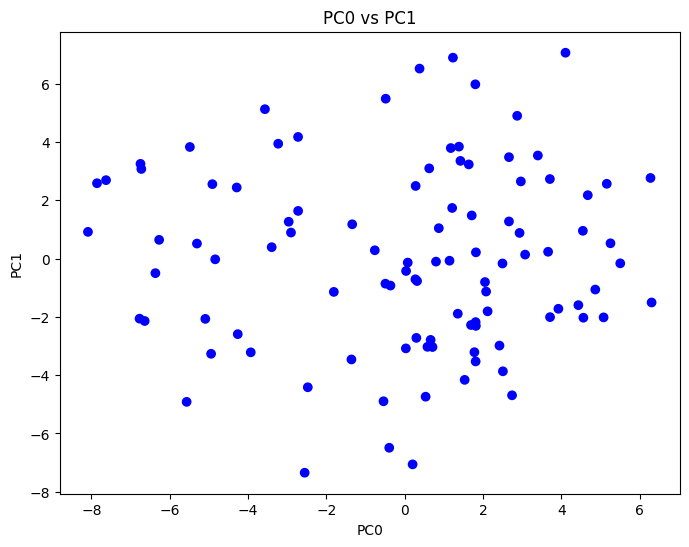

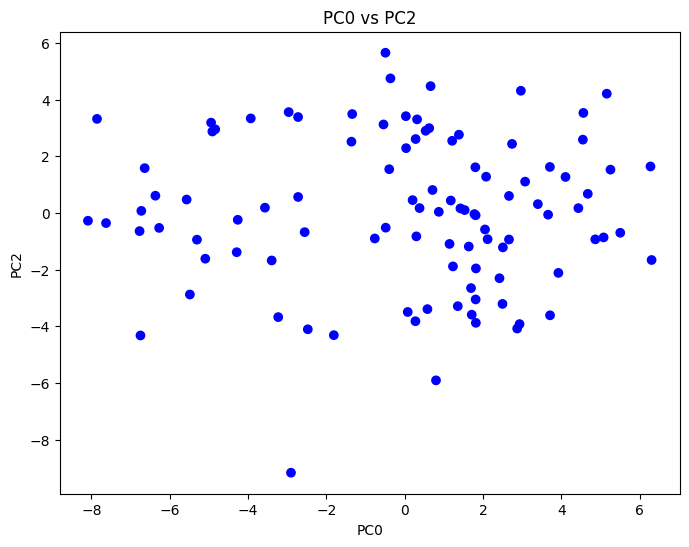

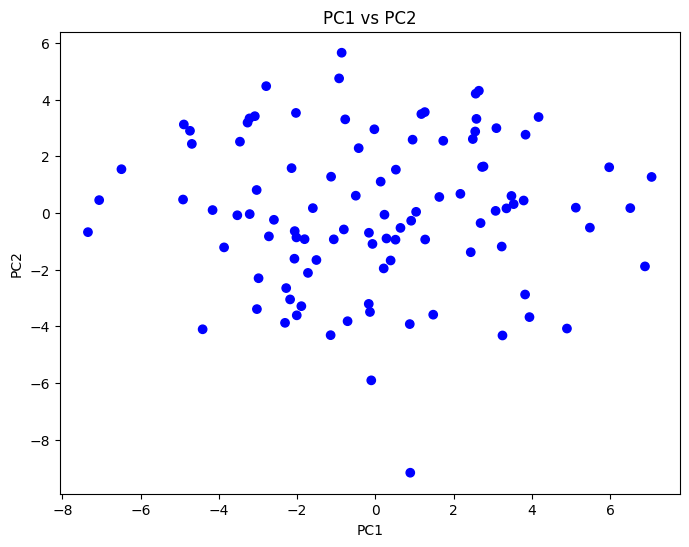

In [13]:
import matplotlib.pyplot as plt

# Function to create a scatter plot
def plot_pca_scatter(x, y, xlabel, ylabel, color_labels):
    # Map 'Alzheimer' to blue and 'cancer' to red
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, c=color_labels.map({'Alzheimer': 'blue', 'cancer': 'red'}))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(f'{xlabel} vs {ylabel}')
    plt.show()

# PC0 vs PC1
plot_pca_scatter(embeddings_pca['PC0'], embeddings_pca['PC1'], 'PC0', 'PC1', embeddings_pca['query'])

# PC0 vs PC2
plot_pca_scatter(embeddings_pca['PC0'], embeddings_pca['PC2'], 'PC0', 'PC2', embeddings_pca['query'])

# PC1 vs PC2
plot_pca_scatter(embeddings_pca['PC1'], embeddings_pca['PC2'], 'PC1', 'PC2', embeddings_pca['query'])

### Analysis of the Separation or Lack Thereof:

The PCA plots reveal that there is no noticeable separation between Alzheimer's and cancer papers, as all points are represented in the same color (blue), suggesting a labeling issue or a lack of categorical distinction in the data. This lack of separation indicates that the SPECTER embeddings for the two groups may overlap significantly, possibly due to shared research topics or similar language used across papers on both diseases.

A potential reason for the overlap is that Alzheimer's and cancer papers might discuss common biological pathways or methodologies, leading to similar embeddings. Another possibility is that the embedding model was not able to distinguish between these two topics in the reduced dimensionality.

The main takeaway is that there is no evident difference in the embeddings between the two categories in the PCA space, possibly due to content similarity or errors in labeling. Further steps, like ensuring proper query labeling or using advanced dimensionality reduction techniques like t-SNE or UMAP, may help improve the separation.
